# Trabajo Práctico Integrador - Introducción al Análisis de Datos
## ***Segunda Parte***: Preparación y Transformación de Datos

**Caso:** análisis y predicción de cancelaciones en reservas hoteleras.

> La empresa busca comprender qué factores influyen en la cancelación de reservas en hoteles urbanos y resort, analizando variables como fechas de estadía, tipo de cliente, canal de reserva, historial previo y tarifas, con el fin de identificar patrones y mejorar la gestión operativa.




## Desarrollado por

- **Integrantes:** `Matias Carro` y `Hugo Catalan`
- **Comisión:** 11
- **Dataset asignado:** Dataset K
- **Entrega:** Primer Entrega - Semana 3
- **Fecha:** 

## Importación de librerías

### Librerias a utilizar:

- **pandas:** para cargar el dataset y trabajar con datos en forma de tablas (DataFrames).
- **numpy:** para realizar operaciones numéricas y manejar arreglos de forma eficiente.
- **matplotlib (pyplot):** para construir la estructura base de gráficos, controlar ejes, etiquetas y personalizar elementos visuales.
- **seaborn:** para generar visualizaciones estadísticas de alto nivel (histogramas, boxplots, gráficos de barras y mapas de correlación) con estilos claros y comparativos.



In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Versión de Pandas:", pd.__version__)
print("Versión de NumPy:", np.__version__)
print("Versión de Matplotlib:", plt.matplotlib.__version__)
print("Versión de Seaborn:", sns.__version__)
print("\nLibrerías cargadas correctamente.")

Versión de Pandas: 3.0.5
Versión de NumPy: 2.5.2
Versión de Matplotlib: 3.11.1
Versión de Seaborn: 0.13.2

Librerías cargadas correctamente.


## 1. Presentacion del problema

El caso de estudio se centra en el análisis de reservas hoteleras con el objetivo de comprender qué factores están asociados a la cancelación de estadías. El dataset asignado contiene información detallada de cada reserva, incluyendo tipo de hotel, fechas de llegada, duración de la estadía, composición del grupo, país de origen, canal de reserva, tipo de cliente, historial previo, tarifa promedio por noche y características operativas como depósito, agente, pedidos especiales y cambios realizados.


### Relación entre datos, información y conocimiento
En este trabajo partimos de los **datos** que son valores crudos del sistema de reservas: fechas, cantidades, categorías y códigos.  
Mediante el análisis exploratorio estos datos se convierten en **información**, como distribuciones, patrones y diferencias entre reservas canceladas y no canceladas.  
A partir de esa información generamos el **conocimiento** que nos permite entender el comportamiento de los clientes y detectar factores que podrían influir en la cancelación de una reserva.  

Esta relación es clave para el caso: los datos del hotel por sí solos no dicen nada, pero al transformarlos en información y luego interpretarlos, podemos identificar variables relevantes (como `lead_time`, `deposit_type` o `customer_type`) que ayudan a explicar por qué algunas reservas se cancelan y otras no.

### Ciclo de vida del análisis
Este trabajo se enmarca en el ciclo de vida del análisis de datos, que incluye:
1. Obtención del dataset asignado.  
2. Comprensión inicial del problema (cancelaciones hoteleras).  
3. Exploración y limpieza mínima (EDA).  
4. Transformación y preparación de variables relevantes.  
5. Interpretación y comunicación de resultados.

### Variable objetivo
La **variable objetivo** del análisis es **`is_canceled`**, que indica si la reserva fue cancelada (`1`) o no (`0`).  
Su distribución será calculada y analizada en las próximas secciones para comprender el comportamiento general del conjunto de datos y orientar las preguntas del análisis.

### Preguntas iniciales que orientan el trabajo
- ¿Qué características diferencian a las reservas canceladas de las no canceladas?  
- ¿Influyen el tipo de hotel o el canal de reserva en la cancelación?  
- ¿Las reservas con mayor anticipación (`lead_time`) presentan mayor probabilidad de cancelación?  
- ¿Los clientes con pedidos especiales o estacionamiento tienden a cancelar menos?  
- ¿Las políticas de depósito (`deposit_type`) reducen la cancelación?  
- ¿Existen segmentos de mercado con mayor riesgo de cancelación?  


---

## 2. Dataset Asignado

- **Comisión:** 11
- **Dataset asignado:** Dataset K


---

## 3. Carga del dataset

Se carga el Dataset perteneciente a la comisión 11:


In [216]:
df = pd.read_csv("hotel booking TPI grupo K.csv")

print("Dataset cargado correctamente.")


Dataset cargado correctamente.


---

## 4. Resumen del dataset

Resumen de los datos 

In [217]:
filas, columnas = df.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas.")

print("Columnas del dataset:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.info())


El dataset tiene 25000 filas y 32 columnas.
Columnas del dataset:
['booking_id', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'arrival_date', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   booking_id                      25000 non-null  str    
 1   hotel                          

El dataset tiene 25.000 filas y 32 columnas.  
Las variables incluyen información temporal, categórica y numérica relevante para el análisis.


### Diccionario de variables 

| Variable | Traducción | Representación | Tipo de Datos |
|----------|------------|----------------|-----------|
| booking_id | ID de reserva | Identificador único de cada reserva. | str |
| hotel | Tipo de hotel | Indica si la reserva corresponde a City Hotel (Ciudad) o Resort Hotel (Resort). | str |
| is_canceled | Cancelada | Indica si la reserva fue cancelada (1) o no (0). | int64 |
| lead_time | Anticipación | Días entre la fecha de reserva y la fecha de llegada. | int64 |
| arrival_date_year | Año de llegada | Año en el que el huésped llega al hotel. | int64 |
| arrival_date_month | Mes de llegada | Mes en el que el huésped llega al hotel. | str |
| arrival_date_week_number | Semana de llegada | Número de semana del año en la que llega el huésped. | int64 |
| arrival_date_day_of_month | Día del mes de llegada | Día del mes en el que llega el huésped. | int64 |
| arrival_date | Fecha de llegada | Fecha completa de llegada (YYYY-MM-DD). | str |
| stays_in_weekend_nights | Noches de fin de semana | Cantidad de noches en fines de semana. | int64 |
| stays_in_week_nights | Noches de semana | Cantidad de noches de lunes a jueves. | int64 |
| adults | Adultos | Número de adultos en la reserva. | int64 |
| children | Niños | Número de niños en la reserva. | float64 |
| babies | Bebés | Número de bebés en la reserva. | int64 |
| meal | Tipo de comida | Plan de comidas asociado a la reserva (BB, HB, SC, etc.). | str |
| country | País | País de origen del huésped. | str |
| market_segment | Segmento de mercado | Tipo de cliente según el canal de adquisición. | str |
| distribution_channel | Canal de distribución | Canal por el cual se realizó la reserva. | str |
| is_repeated_guest | Huésped repetido | Indica si el cliente ya se alojó anteriormente. | int64 |
| previous_cancellations | Cancelaciones previas | Cantidad de reservas previas canceladas por el cliente. | int64 |
| previous_bookings_not_canceled | Reservas previas no canceladas | Cantidad de reservas previas completadas por el cliente. | int64 |
| reserved_room_type | Habitación reservada | Tipo de habitación solicitada originalmente. | str |
| assigned_room_type | Habitación asignada | Tipo de habitación finalmente asignada. | str |
| booking_changes | Cambios en la reserva | Número de modificaciones realizadas a la reserva. | int64 |
| deposit_type | Tipo de depósito | Política de depósito aplicada. | str |
| agent | Agente | Código del agente que gestionó la reserva. | float64 |
| company | Compañía | Código de la empresa asociada a la reserva. | float64 |
| days_in_waiting_list | Días en lista de espera | Tiempo que la reserva permaneció en espera antes de confirmarse. | int64 |
| customer_type | Tipo de cliente | Clasificación del cliente (Transient, Contract, Group, etc.). | str |
| adr | Tarifa promedio diaria | Precio promedio por noche de la reserva. | float64 |
| required_car_parking_spaces | Estacionamiento requerido | Cantidad de espacios de estacionamiento solicitados. | int64 |
| total_of_special_requests | Pedidos especiales | Número de solicitudes especiales realizadas por el cliente. | int64 |




---

## 5. Diagnóstico y limpieza inicial de datos. Semana 4

Se comienza la limpieza de los datos

### 0. Preparativos

Se crea una copia del dataset original para conservar un respaldo íntegro de los datos. A partir de este punto, todas las modificaciones se realizarán exclusivamente sobre la copia de trabajo.

El dataset original permanece sin alteraciones y funciona como *referencia histórica* ante cualquier revisión o necesidad de volver al estado inicial.

In [218]:
df_original = df.copy()
print("Copia del dataset creada correctamente.")

Copia del dataset creada correctamente.


***Bitácora***: Se crea el documento “Bitácora” para dejar constancia de los problemas detectados, las variables afectadas, las decisiones tomadas y la justificación correspondiente.

In [219]:
registros_bitacora = []

def registrar(problema, variable, decision, justificacion):
    registros_bitacora.append({
        "problema_detectado": problema,
        "variable_afectada": variable,
        "decision_tomada": decision,
        "justificacion": justificacion
    })

### 1. Detección de valores duplicados

Antes de comenzar la limpieza, se revisa si existen registros duplicados en el dataset, ya que podrían generar sesgos al contar dos veces la misma reserva.

En este tipo de datos, dos reservas pueden tener exactamente las mismas características sin ser un error, por lo que solo se consideran duplicados aquellos casos donde todas las columnas coinciden completamente.

Como el dataset no posee un identificador único por reserva, la detección se realiza comparando todas las variables. 

In [220]:
duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


La revisión arrojó **0 duplicados**, por lo que no es necesario aplicar cambios en esta etapa.

---

### Identificación de valores faltantes

Se realiza un vistazo en general de los valores faltantes del dataset completo


In [221]:
faltantes = df.isnull().sum().sort_values(ascending=False)
print("Valores faltantes por variable:\n")
print(faltantes)


Valores faltantes por variable:

company                           23574
agent                              3489
country                             101
booking_id                            0
arrival_date_year                     0
arrival_date_month                    0
is_canceled                           0
hotel                                 0
arrival_date_day_of_month             0
arrival_date                          0
stays_in_week_nights                  0
stays_in_weekend_nights               0
adults                                0
children                              0
arrival_date_week_number              0
lead_time                             0
meal                                  0
babies                                0
market_segment                        0
distribution_channel                  0
previous_bookings_not_canceled        0
reserved_room_type                    0
is_repeated_guest                     0
previous_cancellations                0
booking

**Diagnóstico inicial de valores faltantes**

***1. company - 23.574 faltantes***

Código administrativo de empresa asociada a la reserva, la mayoría de las reservas no pertenecen a ninguna compañía.  

No aporta información analítica útil para explicar cancelaciones.  

***2. agent - 3.489 faltantes***

Código interno del agente que gestionó la reserva, los faltantes representan reservas hechas sin agente.  
No es una categoría analítica, sino un identificador, no importa informacion para analizar el motivo de las cancelaciones.  

***3. country - 101 faltantes***

Única variable relevante con faltantes reales, los 101 registros sin país pueden deberse a reservas incompletas, carga manual o canales que no reportan país.  
El porcentaje es muy bajo, se debe verificar que hacer con la variable. Se vera en etapas proximas.

---

### 2. Selección de variables

Como parte del análisis inicial, se revisan todas las columnas del dataset para identificar variables que no aporten información relevante al estudio o que no resulten útiles para el análisis de cancelaciones. Este paso permite simplificar el dataset y concentrar el trabajo en las variables que realmente contribuyen a explicar el comportamiento de las reservas.

En nuestro caso, se inspeccionan nuevamente las columnas del DataFrame y se evalúa si alguna corresponde a identificadores irrelevantes, códigos internos, variables redundantes o información que no será utilizada en el análisis. Tras esta revisión, se determina si es necesario eliminar alguna columna o si todas deben conservarse para las etapas posteriores.

In [222]:
lista_variables = df.columns.tolist()
print(f"Listado de variables:\n{lista_variables}")

print("\nVista inicial de la tabla:\n")
df.head()


Listado de variables:
['booking_id', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'arrival_date', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Vista inicial de la tabla:



,booking_id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,HB-014269,Resort Hotel,0,17,2025,February,8,21,2025-02-21,0,...,E,0,No Deposit,NaN,292.0,0,Transient,58.00,1,1
1,HB-018087,Resort Hotel,0,6,2023,November,44,1,2023-11-01,2,...,D,3,No Deposit,240.0,NaN,0,Transient,58.00,0,2
2,HB-022870,Resort Hotel,0,45,2024,April,15,8,2024-04-08,0,...,D,1,No Deposit,240.0,NaN,0,Transient-Party,65.00,0,2
3,HB-048154,City Hotel,0,95,2024,March,11,17,2024-03-17,2,...,A,0,No Deposit,9.0,NaN,0,Transient,73.95,0,1
4,HB-060351,City Hotel,1,277,2024,November,45,7,2024-11-07,1,...,A,0,Non Refund,NaN,NaN,0,Transient,100.00,0,0


### Booking_id 

Se revisa la variable para evaluar si aporta informacion a la hora de realizar el analisis.

In [223]:
registros = len(df)

booking_registros = df['booking_id'].nunique()

print(f"Registros totales en el Dataset: {registros} - Registro unicos en Booking_id: {booking_registros}")



Registros totales en el Dataset: 25000 - Registro unicos en Booking_id: 25000


La variable `booking_id` contiene un valor único para cada registro del dataset.
Al verificar la cantidad de valores únicos, se observa que coincide exactamente con la cantidad total de filas, lo que confirma que funciona únicamente como identificador.
Este tipo de variables no guarda relación con las demás características de la reserva y no aporta información útil para el análisis de cancelaciones. Solamente se trata de un identificador

Por lo tanto, `booking_id` no será utilizada en el análisis exploratorio y puede excluirse de las etapas de diagnóstico y limpieza.

In [224]:
#Se elimina booking_id
df.drop(columns=['booking_id'], inplace=True)

print("booking_id eliminado correctamente")


booking_id eliminado correctamente


Se registra el cambio en la bitácora

In [225]:
#Se registra el evento
registrar(
    problema="Variable sin aporte analítico",
    variable="booking_id",
    decision="Eliminación de la columna",
    justificacion="booking_id es un identificador único que no se relaciona con las demás variables y no aporta información para explicar cancelaciones."
)


---
### Hotel



In [226]:
# Diagnóstico de la variable hotel
print("Faltantes:")
print(df['hotel'].isnull().sum())

print("\nTipo de dato:", df['hotel'].dtype)

print("\nValores distintos")
print(df['hotel'].nunique())

print("\nValores de la variable:")
print(list(df['hotel'].unique()))

print("\nDistribución")
print(df['hotel'].value_counts())

Faltantes:
0

Tipo de dato: str

Valores distintos
2

Valores de la variable:
['Resort Hotel', 'City Hotel']

Distribución
hotel
City Hotel      16716
Resort Hotel     8284
Name: count, dtype: int64


**Diagnóstico de la variable `Hotel`**

**Completitud**  
La variable se encuentra completamente registrada en todas las filas del dataset. No presenta valores faltantes y no requiere ningún tipo de tratamiento adicional.

**Validez**  
Las dos categorías observadas *City Hotel* y *Resort Hotel* tienen con el contexto del conjunto de datos y no se detectan valores fuera de lo esperado ni categorías que indiquen errores de carga.

**Consistencia**  
Las categorías estan escritas de manera uniforme, sin variaciones en mayúsculas, espacios, guiones o errores de tipeo. 

La Variable `hotel` no requiere ningun tipo de tratamiento, por lo tanto no se asienta en la Bitacora.



In [227]:
registrar(
    problema="Ninguno (variable completa y consistente)",
    variable="hotel",
    decision="Conservar sin modificaciones",
    justificacion="Variable categórica binaria limpia, sin valores nulos ni categorías erróneas. Presenta variabilidad adecuada y es clave para segmentar cancelaciones entre tipos de establecimiento."
)

---
### Is Cancelled 



In [228]:
print("Faltantes:")
print(df['is_canceled'].isnull().sum())

print("\nValores distintos:")
print(df['is_canceled'].nunique())

print("\nValores de la variable:")
print(list(df['is_canceled'].unique()))



Faltantes:
0

Valores distintos:
2

Valores de la variable:
[np.int64(0), np.int64(1)]


**Diagnóstico de la variable `is_canceled`**

**Completitud**  
La variable se encuentra completamente registrada en todas las filas del dataset. No presenta valores faltantes y no requiere tratamiento adicional.

**Validez**  
Los valores observados (0 y 1) tienen sentido en la variable. No se detectan valores fuera de este conjunto.

**Consistencia**  
La variable mantiene un formato uniforme en todo el dataset. No existen variantes como “Yes/No”, “Canceled/Not canceled” ni valores mal tipeados. Tampoco se observan inconsistencias entre registros que indiquen errores de carga.

**Unicidad**  
La variable no funciona como identificador ni presenta valores únicos por fila. Al contener únicamente dos categorías repetidas en miles de registros, su comportamiento es el esperado para una variable binaria y no cumple ninguna condición para ser considerada un ID.

### Conclusión  
La variable `is_canceled` se encuentra completa, válida, consistente y precisa. Es la variable esencial al analisism el objetivo del estudio. No requiere limpieza ni transformación.


In [229]:
# Registro 3
registrar(
    problema="Ninguno (variable completa y consistente)",
    variable="is_canceled",
    decision="Conservar sin modificaciones (Variable central para el analisis)",
    justificacion="Variable binaria codificada en {0, 1} sin valores faltantes ni inconsistencias. Representa la variable objetivo del estudio"
)

---
### Lead Time



In [230]:
print("Faltantes:")
print(df['lead_time'].isnull().sum())

print("\nValores distintos:")
print(df['lead_time'].nunique())

print("\nTipos de Datos en la variable")
print(df['lead_time'].dtype)

print("\nValores negativos (Imposibles - Errores)")
print((df['lead_time'] < 0).sum())

print("\nValor mínimo:", df['lead_time'].min())
print("Valor máximo:", df['lead_time'].max())

#Calculo de Outliers con IQR

print("\nOutliers:")

Q1 = df['lead_time'].quantile(0.25)
Q3 = df['lead_time'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR

print("\nLímite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['lead_time'] > lim_sup).sum())

# Outliers con Z-score

mean = df['lead_time'].mean()
std = df['lead_time'].std()

lim_sup_z = mean + 3 * std

print("\nLímite superior (Z-score):", lim_sup_z)

outliers_z = df[df['lead_time'] > lim_sup_z]

print("Cantidad de outliers (Z-score):", len(outliers_z))




Faltantes:
0

Valores distintos:
460

Tipos de Datos en la variable
int64

Valores negativos (Imposibles - Errores)
0

Valor mínimo: 0
Valor máximo: 629

Outliers:

Límite superior (IQR): 370.5
Cantidad de outliers (IQR): 652

Límite superior (Z-score): 423.04081825080823
Cantidad de outliers (Z-score): 300


**Diagnóstico de la variable `lead_time`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un valor numérico válido que representa la cantidad de días entre la reserva y la fecha de llegada.

**Validez**  
El tipo de dato es `int64`, lo que nos dice que no tenemos ningun string con caracteres, son todos valores numericos. No se detectan valores negativos, lo cual confirma que no existen errores obvios de carga (el tiempo de anticipación no puede ser menor que cero).

**Rango de valores**  
El valor mínimo observado es **0**, correspondiente a reservas realizadas el mismo día de llegada.  
El valor máximo es **629**, lo que indica reservas hechas con más de un año y medio de anticipación. Este valor es posible dentro del contexto del negocio, aunque poco frecuente.

**Variabilidad**  
La variable presenta **460 valores distintos**, lo que indica una variabilidad amplia y útil para análisis estadístico. 

**Detección de outliers**

Se aplicaron dos métodos estadísticos para identificar valores atípicos: **IQR** y **Z‑score**.

**1. Método IQR (Interquartile Range)**  
- Q1 = 18  
- Q3 = 159  
- IQR = 141  
- **Límite superior:** 370.5  
- **Outliers detectados:** 652 registros

Todos los valores superiores a **370.5 días** se consideran outliers estadísticos.  
Estos valores no son errores, pero representan reservas realizadas con mucha anticipación y deben documentarse como casos extremos.

**2. Método Z‑score (Regla de los 3 sigmas)**  
- Media = 103.28  
- Desvío estándar = 106.58  
- **Límite superior:** 423.04  
- **Outliers detectados:** 300 registros

Los valores superiores a **423 días** se consideran outliers según este método.  
El método Z‑score detecta menos outliers porque su límite es más alto que el del IQR.

**Conclusión**

La variable `lead_time` es completa, válida y los datos tienen sentido.  
No presenta valores imposibles ni errores de carga.  
Ambos métodos estadísticos detectan valores extremadamente altos (entre 370 y 629 días), que deben considerarse como *outliers* y se deben tener en cuenta al momento de la transformacion de los datos.

Se agrega a la bitacora:

In [231]:
registrar(
    problema="Valores extremadamente altos (outliers)",
    variable="lead_time",
    decision="Mantener sin modificaciones de limpieza, considerar discretización en la etapa de transformación",
    justificacion="Valores por encima de 370–423 días son estadísticamente atípicos. No son errores, pero pueden distorsionar métricas."
)


---

### Arrival date year

Analisis de la variable

In [232]:
print("Faltantes:")
print(df['arrival_date_year'].isnull().sum())

print("\nValores distintos:")
print(df['arrival_date_year'].nunique())

print("\nValores de la variable:")
valores = sorted(df['arrival_date_year'].astype(int).unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['arrival_date_year'].dtype)

print("\nValores imposibles (años fuera de rango lógico)")
print(df[(df['arrival_date_year'] < 2000) | (df['arrival_date_year'] > 2026)].shape[0])

print("\nValor mínimo:", df['arrival_date_year'].min())
print("Valor máximo:", df['arrival_date_year'].max())



Faltantes:
0

Valores distintos:
3

Valores de la variable:
[2023, 2024, 2025]

Tipos de Datos en la variable
int64

Valores imposibles (años fuera de rango lógico)
0

Valor mínimo: 2023
Valor máximo: 2025



**Diagnóstico de la variable `arrival_date_year`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un año válido.

**Validez**  
El tipo de dato es `int64`, representan años del calendario. No se detectan valores imposibles: comprenden los años 2023 - 2025.

**Rango de valores**  
El valor mínimo es **2023** y el máximo es **2025**, coincidiendo con el período cubierto por el dataset. No se observan errores de carga ni valores erroneos.

**Conclusión**  
La variable `arrival_date_year` es completa, válida y consistente. No presenta valores imposibles, errores de carga ni outliers. No requiere acciones de limpieza.


In [233]:
registrar(
    problema="Ninguno en calidad de datos (variable temporal completa)",
    variable="arrival_date_year",
    decision="Conservar sin modificaciones de limpieza",
    justificacion="Variable temporal completa (sin nulos) y válida (años 2023 a 2025). Indispensable para estudiar la evolución del volumen de reservas y cancelaciones año a año."
)

---

### Arrival date month

Analisis de la variable

In [234]:
print("Faltantes:")
print(df['arrival_date_month'].isnull().sum())

print("\nValores distintos:")
print(df['arrival_date_month'].nunique())

print("\nValores de la variable:")
print(sorted(df['arrival_date_month'].unique()))

print("\nTipos de Datos en la variable")
print(df['arrival_date_month'].dtype)

#Lista con los nombres correctos de los meses
print("\nValores imposibles (meses mal cargados)")
meses_validos = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

#Busca valores que NO esten en la lista de los meses correctos
print(df[~df['arrival_date_month'].isin(meses_validos)].shape[0])


Faltantes:
0

Valores distintos:
12

Valores de la variable:
['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']

Tipos de Datos en la variable
str

Valores imposibles (meses mal cargados)
0


**Diagnóstico de la variable `arrival_date_month`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un mes válido.

**Validez**  
El tipo de dato es `str`, representan los meses como texto. No se detectan valores erroneos: los 12 meses del año están correctamente escritos y sin abreviaturas ni errores tipográficos.

**Variabilidad**  
La variable presenta **12 valores distintos**, correspondientes a los meses del año. 

**Valores de la variable**  
Los meses presentes son: April, August, December, February, January, July, June, March, May, November, October y September. Todos son meses válidos.

**Conclusión**  
La variable `arrival_date_month` es completa, válida y consistente. No presenta valores imposibles, errores de carga ni problemas de formato. No requiere acciones de limpieza.


In [235]:
# Registro 6
registrar(
    problema="Ninguno en calidad de datos (variable temporal íntegra en formato texto)",
    variable="arrival_date_month",
    decision="Conservar sin modificaciones de limpieza. realizar mapeo ordinal (1 a 12) en transformación",
    justificacion="No presenta valores nulos ni inconsistencias (contiene los 12 meses válidos). Se conserva en texto para el análisis exploratorio y en proxima etapa codificar de manera ordinal (1 a 1) para ordenar cronológicamente"
)

---

### arrival_date_week_number

Analisis de la variable


In [236]:
print("Faltantes:")
print(df['arrival_date_week_number'].isnull().sum())

print("\nValores distintos:")
print(df['arrival_date_week_number'].nunique())

print("\nValores de la variable:")

valores = sorted(df['arrival_date_week_number'].astype(int).unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['arrival_date_week_number'].dtype)

print("\nValores imposibles (semanas fuera de rango 1-52)")
print(df[(df['arrival_date_week_number'] < 1) | (df['arrival_date_week_number'] > 52)].shape[0])

print("\nValor mínimo:", df['arrival_date_week_number'].min())
print("Valor máximo:", df['arrival_date_week_number'].max())


Faltantes:
0

Valores distintos:
52

Valores de la variable:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

Tipos de Datos en la variable
int64

Valores imposibles (semanas fuera de rango 1-52)
0

Valor mínimo: 1
Valor máximo: 52



**Diagnóstico de la variable `arrival_date_week_number`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un número de semana válido.

**Validez**  
El tipo de dato es `int64`, representando correctamente semanas del año como números enteros. No se detectan valores erróneos, todas las semanas están dentro del rango lógico (1 a 52).

**Variabilidad**  
La variable presenta *52 valores distintos*, correspondientes a todas las semanas del año. Esto confirma que la codificación es completa y consistente.

**Valores de la variable**  
Los valores presentes abarcan todas las semanas del año, desde la *1* hasta la *52*, sin semanas faltantes ni errores.

**Conclusión**  
La variable `arrival_date_week_number` es completa, válida y consistente. No presenta valores imposibles, errores de carga ni problemas de formato.


Se evalua si la variable aporta informacion a la hora de realizar el analisis.

La variable `arrival_date_week_number` indica el número de semana del año, pero su información es redundante comparado a las variables `arrival_date_year`, `arrival_date_month` y `arrival_date_day_of_month`, que ya permiten analizar el comportamiento temporal de las reservas. Es una variable para uso interno de la empresa, que no aporta información adicional relevante para el estudio de cancelaciones, se decide su eliminacion.

In [237]:
registrar(
    problema="Variable redundante",
    variable="arrival_date_week_number",
    decision="Eliminación de la columna",
    justificacion="La información de semana del año es redundante frente a year, month y day_of_month."
)



---

### Arrival date day of month

Analisis de la variable

In [238]:
print("Faltantes:")
print(df['arrival_date_day_of_month'].isnull().sum())

print("\nValores distintos:")
print(df['arrival_date_day_of_month'].nunique())

print("\nValores de la variable:")
valores = sorted(df['arrival_date_day_of_month'].astype(int).unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['arrival_date_day_of_month'].dtype)

print("\nValores imposibles (días fuera de rango 1-31)")
print(df[(df['arrival_date_day_of_month'] < 1) | (df['arrival_date_day_of_month'] > 31)].shape[0])

print("\nValor mínimo:", df['arrival_date_day_of_month'].min())
print("Valor máximo:", df['arrival_date_day_of_month'].max())


Faltantes:
0

Valores distintos:
31

Valores de la variable:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

Tipos de Datos en la variable
int64

Valores imposibles (días fuera de rango 1-31)
0

Valor mínimo: 1
Valor máximo: 31


**Diagnóstico de la variable `arrival_date_day_of_month`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un día válido del mes.

**Validez**  
El tipo de dato es `int64`, representando correctamente días del mes como números enteros. No se detectan valores fuera del rango lógico (1 a 31).

**Variabilidad**  
La variable presenta *31 valores distintos*, correspondientes a todos los días posibles del mes.

**Valores de la variable**  
Los valores presentes van desde el día *1* hasta el *31*, sin saltos ni valores imposibles.

**Evaluación de aporte analítico**  
La variable `arrival_date_day_of_month` aporta información temporal detallada que puede ser útil para analizar patrones de reservas y cancelaciones dentro de cada mes. No es redundante frente a otras variables temporales, ya que permite estudiar comportamientos específicos según el día del mes.

**Conclusión**  
La variable `arrival_date_day_of_month` es completa, válida y consistente. No presenta valores imposibles ni errores de carga. Se considera útil para el análisis.


In [239]:
registrar(
    problema="Ninguno",
    variable="arrival_date_day_of_month",
    decision="Conservar sin modificaciones",
    justificacion="Presenta valores válidos del 1 al 31 sin nulos. Permite analizar patrones según el momento del mes (comienzo, quincena o fin de mes)."
)

---

### Arrival Date

Se revisa la variable verficiar su integridad y evaluar si aporta informacion a la hora de realizar el analisis.

In [240]:
print("Faltantes:")
print(df['arrival_date'].isnull().sum())

print("\nValores distintos:")
print(df['arrival_date'].nunique())

print("\nTipos de Datos en la variable")
print(df['arrival_date'].dtype)


#Valores erroneos

#Patron REGEX para verificar que las fechas sean todas correctas
patron = r'^\d{4}-\d{2}-\d{2}$'

invalidos = df[~df['arrival_date'].astype(str).str.match(patron)]

print("\nFechas con formato inválido (aaaa-mm-dd):", invalidos.shape[0])
invalidos.head()

print("\nValores imposibles (fechas fuera de rango lógico)")
# Se utiliza un rango que sabemos que el dataset tiene que manejar
print(df[(df['arrival_date'] < '2020-01-01') | (df['arrival_date'] > '2026-12-31')].shape[0])

print("\nValor mínimo:", df['arrival_date'].min())
print("Valor máximo:", df['arrival_date'].max())


Faltantes:
0

Valores distintos:
793

Tipos de Datos en la variable
str

Fechas con formato inválido (aaaa-mm-dd): 0

Valores imposibles (fechas fuera de rango lógico)
0

Valor mínimo: 2023-07-01
Valor máximo: 2025-08-31


**Conclusion del analisis**

La variable `arrival_date` es válida y consistente, pero no aporta información adicional relevante para el análisis de cancelaciones.  

In [241]:
df[['arrival_date', 
    'arrival_date_year', 
    'arrival_date_month', 
    'arrival_date_day_of_month',
    'arrival_date_week_number'
]].head()


,arrival_date,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date_week_number
0,2025-02-21,2025,February,21,8
1,2023-11-01,2023,November,1,44
2,2024-04-08,2024,April,8,15
3,2024-03-17,2024,March,17,11
4,2024-11-07,2024,November,7,45


La columna `arrival_date` contiene la fecha completa de llegada, pero su información ya está desagregada en `arrival_date_year`, `arrival_date_month`, `arrival_date_day_of_month`

Para el analisis, `arrival_date` es redundante, ya que no aporta datos nuevos respecto a las demás variables con datos de fechas que se pueden utilizar para analizar las temporadas del año, mediado del mes de la reserva, años con más o menos reservas o cancelaciones. 

Por este motivo, se propone su eliminación en la etapa de transformación.


Se registra el cambio en la bitácora

In [242]:
registrar(
    problema="Variable redundante",
    variable="arrival_date",
    decision="Revisar en etapa de transformación",
    justificacion="La fecha completa no aporta información adicional frente a year, month y day_of_month. Se decide eliminar la variable."
)


### stays in weekend nights

Analisis de la variable

In [243]:
print("Faltantes:")
print(df['stays_in_weekend_nights'].isnull().sum())

print("\nValores distintos:")
print(df['stays_in_weekend_nights'].nunique())

print("\nValores de la variable:")
valores = sorted(df['stays_in_weekend_nights'].astype(int).unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['stays_in_weekend_nights'].dtype)

print("\nValores imposibles (noches negativas)")
print((df['stays_in_weekend_nights'] < 0).sum())

print("\nValor mínimo:", df['stays_in_weekend_nights'].min())
print("Valor máximo:", df['stays_in_weekend_nights'].max())

#Outliers

#Calculo de Outliers con IQR

print("\nOutliers:")

Q1 = df['stays_in_weekend_nights'].quantile(0.25)
Q3 = df['stays_in_weekend_nights'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR

print("\nLímite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['stays_in_weekend_nights'] > lim_sup).sum())

# Outliers con Z-score

mean = df['stays_in_weekend_nights'].mean()
std = df['stays_in_weekend_nights'].std()

lim_sup_z = mean + 3 * std

print("\nLímite superior (Z-score):", lim_sup_z)

outliers_z = df[df['stays_in_weekend_nights'] > lim_sup_z]

print("Cantidad de outliers (Z-score):", len(outliers_z))


Faltantes:
0

Valores distintos:
12

Valores de la variable:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14]

Tipos de Datos en la variable
int64

Valores imposibles (noches negativas)
0

Valor mínimo: 0
Valor máximo: 14

Outliers:

Límite superior (IQR): 5.0
Cantidad de outliers (IQR): 59

Límite superior (Z-score): 3.890320161777353
Cantidad de outliers (Z-score): 466


**Diagnóstico de la variable `stays_in_weekend_nights`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un número válido de noches de fin de semana.

**Validez**  
El tipo de dato es `int64`, representando correctamente cantidades enteras de noches. No se detectan valores imposibles: no hay noches negativas.


**Detección de outliers**  
Se evaluaron posibles valores atípicos mediante dos métodos:

- **IQR (Interquartile Range)**  
  - Límite superior: **5.0**  
  - Cantidad de outliers: **59**  
  Estos valores corresponden a huéspedes que se alojaron más de 5 noches en fin de semana. Son casos poco frecuentes, pero posibles.

- **Z-score (3 desviaciones estándar)**  
  - Límite superior: **3.89**  
  - Cantidad de outliers: **466**  
  Este método considera como atípicos valores moderados (4, 5, 6 noches) debido a la fuerte concentración en 0, 1 y 2 noches.  
  Sin embargo, estos valores siguen siendo posibles y no representan errores de carga.

En ambos métodos, los valores detectados como outliers validos y reflejan estancias inusualmente largas, pero posibles.

**Conclusión**  

`stays_in_weekend_nights` esta completa, válida y útil para el análisis.  
Los valores considerados outliers son plausibles y no requieren eliminación.  
La variable  aporta información relevante para el análisis del comportamiento de los huéspedes.  
Permite estudiar patrones de demanda en fines de semana, diferencias entre reservas cortas y largas, y posibles relaciones con cancelaciones o estacionalidad.  







In [244]:
# Registro 10
registrar(
    problema="Division de la informacion de la estadia total",
    variable="stays_in_weekend_nights",
    decision="Conservar sin modificaciones en limpieza. Ralizar una unión en transformación",
    justificacion="No contiene valores nulos ni negativos. Los valores atípicos reflejan estadías prolongadas reales. En transformación se sumará con stays_in_week_nights para obtener la estadía total."
)

---

### Stays in week nights

Analisis de la variable

In [245]:
print("Faltantes:")
print(df['stays_in_week_nights'].isnull().sum())

print("\nValores distintos:")
print(df['stays_in_week_nights'].nunique())

print("\nValores de la variable:")
valores = sorted(df['stays_in_week_nights'].astype(int).unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['stays_in_week_nights'].dtype)

print("\nValores imposibles (noches negativas)")
print((df['stays_in_week_nights'] < 0).sum())

print("\nValor mínimo:", df['stays_in_week_nights'].min())
print("Valor máximo:", df['stays_in_week_nights'].max())

# Outliers con IQR
print("\nOutliers (IQR):")

Q1 = df['stays_in_week_nights'].quantile(0.25)
Q3 = df['stays_in_week_nights'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR

print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['stays_in_week_nights'] > lim_sup).sum())

# Outliers con Z-score
mean = df['stays_in_week_nights'].mean()
std = df['stays_in_week_nights'].std()

lim_sup_z = mean + 3 * std

print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['stays_in_week_nights'] > lim_sup_z).sum())


Faltantes:
0

Valores distintos:
25

Valores de la variable:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 34]

Tipos de Datos en la variable
int64

Valores imposibles (noches negativas)
0

Valor mínimo: 0
Valor máximo: 34

Outliers (IQR):
Límite superior (IQR): 6.0
Cantidad de outliers (IQR): 662

Límite superior (Z-score): 8.115568076228653
Cantidad de outliers (Z-score): 349


**Diagnóstico de la variable `stays_in_week_nights`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un número válido de noches entre semana.

**Validez**  
El tipo de dato es `int64`, representando correctamente cantidades enteras de noches. No se detectan valores imposibles, no hay noches negativas.

**Variabilidad**  
La variable presenta **25 valores distintos**, lo cual es esperable dado que representa la cantidad de noches entre semana que un huésped permanece en el hotel.

**Valores de la variable**  
Los valores van desde **0** hasta **34** noches.  
La distribución muestra que la mayoría de los huéspedes se alojan entre 1 y 3 noches entre semana, aunque existen estancias prolongadas que llegan a más de 20 noches.

**Detección de outliers**  
Se evaluaron posibles valores atípicos mediante dos métodos:

- **IQR (Interquartile Range)**  
  - Límite superior: *6.0*  
  - Cantidad de outliers: *662*  
  Estos valores corresponden a huéspedes con estancias largas entre semana. Son poco frecuentes, pero plausibles.

- **Z-score (3 desviaciones estándar)**  
  - Límite superior: *8.11*  
  - Cantidad de outliers: *349*  
  Este método marca como atípicos valores altos debido a la fuerte concentración en estancias cortas.  
  Sin embargo, los valores detectados siguen siendo posibles en reservas extendidas.

En ambos métodos, los valores considerados outliers **son válidos** y no representan errores de carga.

**Conclusión**  
`stays_in_week_nights` es completa, válida y útil para el análisis.  
Los valores considerados outliers son plausibles y no requieren eliminación.  
La variable aporta información esencial para el análisis del comportamiento de los huéspedes.  
Permite estudiar patrones de demanda entre semana, identificar estancias prolongadas, analizar diferencias entre reservas cortas y largas, y evaluar su relación con cancelaciones y estacionalidad.  






In [246]:
registrar(
    problema="Segmentación fragmentada de la estadía y estadías prolongadas legítimas",
    variable="stays_in_week_nights",
    decision="Conservar sin modificaciones en limpieza. Planificar unión (derivación de totales) en transformación",
    justificacion="Variable numérica entera sin valores nulos ni inconsistencias. En transformación se sumará con stays_in_week_nights para obtener la estadía total."
)

### Revision de estadias erroneas

Se revisa si existen datos erroneos en la cantidad de noches de estadia (se verifica que una estadia no tenga 0 noches y 0 dias)

In [247]:
# Condicion logica - ambas columnas de noches iguales a 0
noches_cero = (df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)

#Contar la cantidad de registros que la cumplen
cantidad_cero = noches_cero.sum()
porcentaje = (cantidad_cero / len(df)) * 100

print(f"Cantidad de reservas con 0 noches: {cantidad_cero}")
print(f"Porcentaje respecto al total: {porcentaje:.2f}%")

adr_cero = (df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0 & (df['adr'] == 0))

noches_adr_cero = adr_cero.sum()

print(f"\nEstadias con noche 0 y ADR 0: {noches_adr_cero}")

print("\nResumen de las estadias con 0 noches:")
# mostrar las primeras filas con 0 noches
df[noches_cero].head(10)

Cantidad de reservas con 0 noches: 147
Porcentaje respecto al total: 0.59%

Estadias con noche 0 y ADR 0: 147

Resumen de las estadias con 0 noches:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,stays_in_week_nights,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
93,Resort Hotel,0,41,2025,January,3,17,2025-01-17,0,0,...,A,1,No Deposit,NaN,NaN,0,Transient-Party,0.0,0,0
261,City Hotel,0,0,2025,June,24,14,2025-06-14,0,0,...,A,0,No Deposit,28.0,NaN,0,Transient,0.0,0,0
551,Resort Hotel,0,0,2024,January,4,25,2024-01-25,0,0,...,I,0,No Deposit,240.0,NaN,0,Transient,0.0,0,1
858,Resort Hotel,0,41,2025,January,3,17,2025-01-17,0,0,...,A,3,No Deposit,NaN,NaN,0,Transient-Party,0.0,0,0
924,City Hotel,0,32,2025,January,1,2,2025-01-02,0,0,...,A,0,No Deposit,9.0,NaN,0,Transient,0.0,0,1
1036,City Hotel,0,0,2024,July,29,17,2024-07-17,0,0,...,A,0,No Deposit,NaN,NaN,0,Transient,0.0,0,0
1266,Resort Hotel,0,112,2024,July,31,30,2024-07-30,0,0,...,G,0,No Deposit,240.0,NaN,0,Transient,0.0,0,0
1318,Resort Hotel,0,1,2023,August,31,3,2023-08-03,0,0,...,I,1,No Deposit,240.0,NaN,0,Group,0.0,0,1
1377,Resort Hotel,1,23,2024,January,1,4,2024-01-04,0,0,...,D,0,No Deposit,314.0,NaN,0,Transient,0.0,0,0
1533,Resort Hotel,0,39,2024,October,44,29,2024-10-29,0,0,...,I,0,No Deposit,6.0,NaN,0,Transient,0.0,0,0


Se encuentran 147 filas donde hay 0 noches en total de estadia, se eliminan para quitar este error de las estadisticas.

Ademas se puede ver que hay estadias con ADR = 0, al momento se eliminan las que coinciden con 0 noches en total, mas adelante durante el tratamiento de ADR se vera el problema de las restantes con ADR = 0

In [248]:
#los índices de las filas con 0 noches en ambos campos
indices_cero_noches = df[(df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)].index

# Eliminar esas filas por índice
df= df.drop(index=indices_cero_noches).reset_index(drop=True)

#revision:
print("Revision:")
noches_cero = (df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)

cantidad_cero = noches_cero.sum()
porcentaje = (cantidad_cero / len(df)) * 100

print(f"Cantidad de reservas con 0 noches: {cantidad_cero}")
print("Filas con 0 noches en total eliminadas")


Revision:
Cantidad de reservas con 0 noches: 0
Filas con 0 noches en total eliminadas


**Se regista en la bitacora**

In [249]:

registrar(
    problema="Inconsistencia lógica (estadía total igual a 0 noches)",
    variable="stays_in_weekend_nights & stays_in_week_nights",
    decision="Eliminación de 147 registros mediante filtrado por índice",
    justificacion="Una reserva hotelera válida requiere al menos una noche. Los 147 registros afectados (0.59% del total) carecen de pernocte y facturación, correspondiendo a registros incompletos o de prueba. Su porcentaje es bajo por lo tanto se pueden eliminar"
)

---

### Adults

Analisis de la variable

In [250]:
print("Faltantes:")
print(df['adults'].isnull().sum())

print("\nValores distintos:")
print(df['adults'].nunique())

print("\nValores de la variable:")
valores = sorted(df['adults'].astype(int).unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['adults'].dtype)

print("\nValores imposibles (negativos)")
print((df['adults'] < 0).sum())

print("\nValor mínimo:", df['adults'].min())
print("Valor máximo:", df['adults'].max())

# Outliers con IQR
print("\nOutliers (IQR):")

Q1 = df['adults'].quantile(0.25)
Q3 = df['adults'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR

print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['adults'] > lim_sup).sum())

# Outliers con Z-score
mean = df['adults'].mean()
std = df['adults'].std()

lim_sup_z = mean + 3 * std

print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['adults'] > lim_sup_z).sum())


Faltantes:
0

Valores distintos:
7

Valores de la variable:
[0, 1, 2, 3, 4, 5, 50]

Tipos de Datos en la variable
int64

Valores imposibles (negativos)
0

Valor mínimo: 0
Valor máximo: 50

Outliers (IQR):
Límite superior (IQR): 2.0
Cantidad de outliers (IQR): 1316

Límite superior (Z-score): 3.583495644738199
Cantidad de outliers (Z-score): 16


**Diagnóstico de la variable `adults`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un número válido (Integer).

**Validez**  
El tipo de dato es `int64`, representando correctamente cantidades enteras de personas adultas.  
No se detectan valores imposibles: no hay valores negativos.

**Valores de la variable**  
Los valores van desde **0** hasta **50** adultos.  
La distribución muestra que la mayoría de las reservas incluyen entre 1 y 2 adultos, mientras que los valores altos corresponden a reservas grupales o eventos.

Se encontraron reservas con **0 Adultos** se debe verificar las reservas con numeros errones o extraños de individuos. 

**Detección de outliers**  
Se evaluaron posibles valores atípicos mediante dos métodos:

- **IQR (Interquartile Range)**  
  - Límite superior: **2.0**  
  - Cantidad de outliers: **1318**  
  Estos valores corresponden a reservas con más de 2 adultos. Son poco frecuentes, pero plausibles en reservas grupales o eventos.

- **Z-score (3 desviaciones estándar)**  
  - Límite superior: **3.58**  
  - Cantidad de outliers: **16**  
  Este método identifica únicamente los valores extremadamente altos (como 50 adultos).  
  Aunque son casos raros, siguen siendo posibles en contextos de grupos grandes.

En ambos métodos, los valores considerados outliers **son válidos** pero tiene que tenerse en cuenta al momento de sacar estadisiticas el outlier extremo de 50.

**Conclusión**  
La variable `adults` es completa, válida y útil para el análisis.  
Los valores considerados outliers son plausibles (Aunque el valor de 50 debe considerarse durante el analisis). Pero se encuentran valores 0 (no es posible una reserva sin personas). Se debe revisar el problema 
La variable aporta información esencial para el estudio de la composición de las reservas, permitiendo analizar patrones.

Revision de irregularidades: 

In [251]:
# Inconsistencia - reservas con 0 adultos y ademas 0 personas en total
cero_adultos = (df['adults'] == 0).sum()
cero_huespedes = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)

print(f"\nReservas con 0 adultos: {cero_adultos}")
print(f"\nReservas con 0 huéspedes en total (0 adultos, 0 niños, 0 bebés): {cero_huespedes.sum()}")
#Errores - niños/bebés sin adultos acompañantes
menores_sin_adultos = (df['adults'] == 0) & ((df['children'] > 0) | (df['babies'] > 0))
print(f"\nReservas con 0 adultos pero con niños o bebés: {menores_sin_adultos.sum()}")

#porcentaje de las reservas erroneas

porcentaje_erroneas = (cero_adultos / len(df)) * 100
print(f"\nPorcentaje de reservas con errores: {porcentaje_erroneas:.3f}%")



Reservas con 0 adultos: 63

Reservas con 0 huéspedes en total (0 adultos, 0 niños, 0 bebés): 20

Reservas con 0 adultos pero con niños o bebés: 43

Porcentaje de reservas con errores: 0.253%


**Error encontrado**

Que Exista una reserva con 0 adultos es un error, no deberia existir una reserva sin personas alojadas, hay un total de 63 reservas erroneas que representan un 0.253% del total. Un valor extremadamente bajo

- 0 huéspedes en total (0 adultos, 0 niños, 0 bebés): Es una inconsistencia lógica. No existe reserva sin personas alojadas.

- Menores sin adultos acompañantes (0 adultos con niños o bebés): pueden ser errores de carga o habitaciones conectadas mal registradas.

Al ser un valor tan bajo, se eliminan las filas del Dataset

In [252]:
#Registros inválidos (sin huéspedes o menores sin adultos)
cero_huespedes = (df['adults'] == 0) & (df['children'].fillna(0) == 0) & (df['babies'] == 0)
menores_solos = (df['adults'] == 0) & ((df['children'] > 0) | (df['babies'] > 0))

indices_a_eliminar = df[cero_huespedes | menores_solos].index

#Eliminar del DataFrame de trabajo
df = df.drop(index=indices_a_eliminar).reset_index(drop=True)
#Verificación
print(f"\nReservas con 0 huéspedes en total restantes: {len(indices_a_eliminar)}")
print("Filas erroneas eliminadas")


Reservas con 0 huéspedes en total restantes: 63
Filas erroneas eliminadas


Se registra en la bitacora

In [253]:

registrar(
    problema="Inconsistencia (reservas con 0 huéspedes totales o menores sin adultos)",
    variable="adults, children, babies",
    decision="Eliminación de registros mediante filtrado por índice",
    justificacion="Una reserva válida exige al menos una persona alojada y un adulto responsable. Las reservas con 0 personas o menores solos corresponden a registros truncados o errores. Se eliminan las filas."
)

--- 

### Children

Analisis de la variable 

In [254]:
print("Faltantes:")
print(df['children'].isnull().sum())

print("\nValores distintos:")
print(df['children'].nunique())

print("\nValores de la variable:")
valores = sorted(df['children'].unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['children'].dtype)

print("\nValores imposibles (niños negativos)")
print((df['children'] < 0).sum())

print("\nValor mínimo:", df['children'].min())
print("Valor máximo:", df['children'].max())

# Outliers con IQR
print("\nOutliers (IQR):")

Q1 = df['children'].quantile(0.25)
Q3 = df['children'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR

print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['children'] > lim_sup).sum())

print("Faltantes:")
print(df['children'].isnull().sum())

print("\nValores distintos:")
print(df['children'].nunique())

print("\nValores de la variable:")
valores = sorted(df['children'].unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['children'].dtype)

print("\nValores imposibles (negativos)")
print((df['children'] < 0).sum())

print("\nValor mínimo:", df['children'].min())
print("Valor máximo:", df['children'].max())

# Outliers con IQR
print("\nOutliers (IQR):")

Q1 = df['children'].quantile(0.25)
Q3 = df['children'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR

print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['children'] > lim_sup).sum())

# Outliers con Z-score
mean = df['children'].mean()
std = df['children'].std()

lim_sup_z = mean + 3 * std

print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['children'] > lim_sup_z).sum())

Faltantes:
0

Valores distintos:
4

Valores de la variable:
[0.0, 1.0, 2.0, 3.0]

Tipos de Datos en la variable
float64

Valores imposibles (niños negativos)
0

Valor mínimo: 0.0
Valor máximo: 3.0

Outliers (IQR):
Límite superior (IQR): 0.0
Cantidad de outliers (IQR): 1722
Faltantes:
0

Valores distintos:
4

Valores de la variable:
[0.0, 1.0, 2.0, 3.0]

Tipos de Datos en la variable
float64

Valores imposibles (negativos)
0

Valor mínimo: 0.0
Valor máximo: 3.0

Outliers (IQR):
Límite superior (IQR): 0.0
Cantidad de outliers (IQR): 1722

Límite superior (Z-score): 1.2477481775521706
Cantidad de outliers (Z-score): 694


**Diagnóstico de la variable `children`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un número válido de niños asociados a la reserva.

**Validez**  
El tipo de dato es `float64`, no se detectan valores imposibles, no hay valores negativos. Pero no tiene sentido almacenar un valor entero en floats, se debe cambiar a int las variables para un mejor manejo

**Variabilidad**  
La variable presenta **4 valores distintos**: 0, 1, 2 y 3 niños por reserva.  
La distribución está fuertemente concentrada en **0 niños**, lo cual es esperable en reservas hoteleras.

**Valores de la variable**  
Los valores van desde **0** hasta **3** niños.  
La mayoría de las reservas no incluyen menores, mientras que los valores de 1 y 2 niños representan casos familiares.  
El valor de 3 niños es extremadamente raro.

**Detección de outliers**  
Se evaluaron posibles valores atípicos mediante dos métodos:

- **IQR (Interquartile Range)**  
  - Límite superior: **0.0**  
  - Cantidad de outliers: **1773**  
  Debido a que la mayoría de los registros tienen 0 niños, cualquier valor mayor a 0 queda marcado como outlier por este método.  
  No es un error, refleja la fuerte concentración en el valor 0.

- **Z-score (3 desviaciones estándar)**  
  - Límite superior: **1.27**  
  - Cantidad de outliers: **740**  
  Este método identifica como atípicos los valores más altos (2 y 3 niños).  
  Aunque son casos raros para el dataset, simplemente son familias numerosas.



**Conclusión**  
La variable `children` es completa, válida y útil para el análisis.  
Los valores considerados outliers son plausibles y no requieren eliminación.  
La variable aporta información relevante para el estudio de la composición familiar de las reservas y su relación con cancelaciones, estacionalidad y tipo de estadía.  
Se debe pasar a valores enteros para un mejor manejo de los datos 


In [255]:
# Convertir a tipo entero 
df['children'] = df['children'].astype(int)

# Verificación del tipo de dato
print(f"Nuevo tipo de dato en children: {df['children'].dtype}")

Nuevo tipo de dato en children: int64


Se carga en bitacora

In [256]:
registrar(
    problema="Tipo de dato incompatible (almacenada como float64 en lugar de int64)",
    variable="children",
    decision="Cambio a tipo entero (int64)",
    justificacion="Se convierte a entero por ser discreta ya que no tiene sentido utilizar los datos con decimales."
)

--- 

### Babies

Analisis de la variable

In [257]:
print("Faltantes:")
print(df['babies'].isnull().sum())

print("\nValores distintos:")
print(df['babies'].nunique())

print("\nValores de la variable:")
valores = sorted(df['babies'].unique().tolist())
print(valores)

print("\nTipos de Datos en la variable")
print(df['babies'].dtype)

print("\nValores imposibles (negativos)")
print((df['babies'] < 0).sum())

print("\nValor mínimo:", df['babies'].min())
print("Valor máximo:", df['babies'].max())

# Outliers con IQR
print("\nOutliers (IQR):")

Q1 = df['babies'].quantile(0.25)
Q3 = df['babies'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR

print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['babies'] > lim_sup).sum())

# Outliers con Z-score
mean = df['babies'].mean()
std = df['babies'].std()

lim_sup_z = mean + 3 * std

print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['babies'] > lim_sup_z).sum())


Faltantes:
0

Valores distintos:
5

Valores de la variable:
[0, 1, 2, 9, 10]

Tipos de Datos en la variable
int64

Valores imposibles (negativos)
0

Valor mínimo: 0
Valor máximo: 10

Outliers (IQR):
Límite superior (IQR): 0.0
Cantidad de outliers (IQR): 170

Límite superior (Z-score): 0.3659041808077652
Cantidad de outliers (Z-score): 170


**Diagnóstico de la variable `babies`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros contienen un número válido de bebés asociados a la reserva.

**Validez**  
El tipo de dato es `int64`, representando correctamente cantidades enteras de bebés.  
No se detectan valores imposibles, no hay valores negativos.

**Variabilidad**  
La variable presenta **5 valores distintos**: 0, 1, 2, 9 y 10 bebés por reserva.  
La distribución está fuertemente concentrada en **0 bebés**, lo cual es esperable en reservas hoteleras.  
Los valores 9 y 10 son extremadamente raros y corresponden a casos muy particulares.

**Valores de la variable**  
Los valores van desde **0** hasta **10** bebés.  
La mayoría de las reservas no incluyen menores de un año.  
Los valores 1 y 2 representan casos familiares típicos.  
Los valores 9 y 10 son inusuales y puede tratarse de errores de carga.

**Detección de outliers**  
Se evaluaron posibles valores atípicos mediante dos métodos:

- **IQR (Interquartile Range)**  
  - Límite superior: **0.0**  
  - Cantidad de outliers: **170**  
  Debido a que la mayoría de los registros tienen 0 bebés, cualquier valor mayor a 0 queda marcado como outlier por este método.  


- **Z-score (3 desviaciones estándar)**  
  - Límite superior: **0.3643**  
  - Cantidad de outliers: **170**

  Este método también identifica como atípicos todos los valores mayores a 0.  

  Los valores altos (9 y 10) son extremadamente raros y deben ser tratados



**Conclusión**  
La variable `babies` es completa, válida y útil para el análisis.  
Los valores outlier extremos pueden sesgar las estadistias.  
La variable aporta información relevante para el estudio de la composición familiar de las reservas. Se debe tratar los casos extremos para que no sesguen las estadisticas


In [258]:
# Ver las filas con 9 o 10 bebés
filas_bebes_outliers = df[df['babies'] >= 9]
porcentaje_erroneos = (len(filas_bebes_outliers)) / len(df) * 100

print(f"\nCantidad de casos muy altos: {len(filas_bebes_outliers)}")
print(f"\nPorcentaje de reservas con cantidad alta de bebes: {porcentaje_erroneos:.3f}%")

filas_bebes_outliers[['adults', 'children', 'babies', 'hotel', 'adr', 'is_canceled']]


Cantidad de casos muy altos: 2

Porcentaje de reservas con cantidad alta de bebes: 0.008%


,adults,children,babies,hotel,adr,is_canceled
1396,2,0,10,City Hotel,84.45,0
14439,1,0,9,City Hotel,95.00,0


Debido a que los casos con una cantidad muy alta de bebes es muy bajo (2 solamente, un 0.008%) se procede a eliminarlos del dataset, para evitar sesgar la informacion con datos de outliers muy extremos erroneos.

In [259]:
#Indices de valores imposibles
indices_bebes_imposibles = df[df['babies'] >= 9].index

#Eliminar
df = df.drop(index=indices_bebes_imposibles).reset_index(drop=True)

# 3. Verificación
print(f"Registros eliminados: {len(indices_bebes_imposibles)}")
print(f"Valores resultantes en babies: {sorted(df['babies'].unique().tolist())}")
print("Se elimina correctamente los valores extremadamente altos en babies")

Registros eliminados: 2
Valores resultantes en babies: [0, 1, 2]
Se elimina correctamente los valores extremadamente altos en babies


Se registra en la bitacora

In [260]:
# Registro para babies
registrar(
    problema="Valores imposibles por error de carga (registros con 9 y 10 bebés)",
    variable="babies",
    decision="Eliminación de los registros con valores imposibles (babies >= 9)",
    justificacion="Una reserva con 9 o 10 bebés resulta inverosímil y se trata de un error tipográfico. Al representar un volumen muy bajo (<0.01%), se eliminan los registros para sanear la distribución sin sesgar la muestra"
)

--- 

### Meal

Analisis de la variable 

In [261]:

print("Faltantes:")
print(df['meal'].isnull().sum())

print("\nValores distintos")
print(df['meal'].nunique())

print("\nValores de la variable:")
valores = sorted(df['meal'].unique().tolist())
print(valores)

print("\nVariables que son undefined: ")
lista_comidas_correctas = ['BB', 'FB', 'HB', 'SC']
#Busca valores que NO esten en la lista de comidas correctas
print(df[~df['meal'].isin(lista_comidas_correctas)].shape[0])




Faltantes:
0

Valores distintos
5

Valores de la variable:
['BB', 'FB', 'HB', 'SC', 'Undefined']

Variables que son undefined: 
226


**Diagnóstico de la variable `meal`**

**Completitud**  
La variable no presenta valores faltantes. El 100% de las reservas tiene un régimen alimenticio registrado.

**Validez**  
El tipo de dato es categórico y todos los valores corresponden a códigos válidos del dominio hotelero: `BB`, `FB`, `HB`, `SC`.  
Se detecta además la categoría **`Undefined`**, que representa valores no especificados por el sistema.

**Variabilidad**  
La variable presenta **5 valores distintos**: `BB`, `FB`, `HB`, `SC` y `Undefined`.  
La distribución está fuertemente concentrada en **BB (Bed & Breakfast)**, que es el régimen más común en hoteles.

**Valores de la variable**  
Los valores encontrados son:  
`['BB', 'FB', 'HB', 'SC', 'Undefined']`  
La categoría **Undefined** aparece en **228 registros**, lo cual representa un pequeño porcentaje del dataset, pero suficiente para requerir revisión.

**Detección de valores inválidos o especiales**  
Aunque no existen valores imposibles, la presencia de **Undefined** indica un caso especial:  
- Puede representar datos faltantes codificados.  
- Puede ser una categoría residual del sistema de origen.  
- Puede requerir recodificación en la etapa de transformación.

No se detectan outliers numéricos porque la variable es categórica.

**Conclusión**  
La variable `meal` es completa y válida en términos generales.  
La categoría **Undefined** deberia ser recodificada .


Se agrega a la bitacora:

In [262]:
# Tabla resumen completa de meal (cantidades y porcentajes)
tabla_meal = pd.DataFrame({
    'Cantidad': df['meal'].value_counts(dropna=False),
    'Porcentaje (%)': (df['meal'].value_counts(normalize=True, dropna=False) * 100).round(2)
})

print(tabla_meal)

           Cantidad  Porcentaje (%)
meal                               
BB            19119           77.13
HB             3055           12.32
SC             2241            9.04
Undefined       226            0.91
FB              147            0.59


Si a un huésped no se le definió un plan de comidas (Undefined), en la práctica el hotel no le sirve ninguna comida. Por lo tanto funciona igual que una reserva SC (Self Catering) Es decir, el huesped administra la comida por sus propios medios. Debido a esto se cambian todos los undefined a SC.


In [263]:
# Unificar 'Undefined' en 'SC' (Self Catering)
df['meal'] = df['meal'].replace('Undefined', 'SC')

# Verificación de categorías resultantes y distribución final
print("Valores únicos en meal:")
print(sorted(df['meal'].unique().tolist()))

print("\nDistribución final de frecuencias:")
print(pd.DataFrame({
    'Cantidad': df['meal'].value_counts(),
    'Porcentaje (%)': (df['meal'].value_counts(normalize=True) * 100).round(2)
}))

Valores únicos en meal:
['BB', 'FB', 'HB', 'SC']

Distribución final de frecuencias:
      Cantidad  Porcentaje (%)
meal                          
BB       19119           77.13
HB        3055           12.32
SC        2467            9.95
FB         147            0.59


In [264]:
registrar(
    problema="Datos Undefined",
    variable="meal",
    decision="Recodificación de 'Undefined' a 'SC' (Self Catering)",
    justificacion="Si a un huésped no se le definió un plan de comidas (Undefined), en la práctica el hotel no le sirve ninguna comida. Se cambia de Undefined a SC"
)

---

### Country

Analisis de la variable

In [265]:

print("Faltantes:")
nulos_country = df['country'].isnull().sum()
pct_nulos_country = (nulos_country / len(df)) * 100

print(f"Valores nulos en country: {nulos_country} ({pct_nulos_country:.3f}%)")

print("\nValores distintos")
print(df['country'].nunique())

print("\nTipos de Datos en la variable")
print(df['country'].dtype)

print("\nValores de la variable:")
valores = sorted(df['country'].dropna().unique().tolist())
print(valores)



Faltantes:
Valores nulos en country: 98 (0.395%)

Valores distintos
128

Tipos de Datos en la variable
str

Valores de la variable:
['ABW', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATA', 'ATF', 'AUS', 'AUT', 'AZE', 'BEL', 'BEN', 'BGD', 'BGR', 'BIH', 'BLR', 'BOL', 'BRA', 'CHE', 'CHL', 'CHN', 'CMR', 'CN', 'COL', 'CPV', 'CRI', 'CUB', 'CYP', 'CZE', 'DEU', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'EST', 'FIN', 'FRA', 'FRO', 'GBR', 'GEO', 'GHA', 'GIB', 'GLP', 'GNB', 'GRC', 'GTM', 'HKG', 'HRV', 'HUN', 'IDN', 'IMN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JEY', 'JOR', 'JPN', 'KAZ', 'KOR', 'KWT', 'LAO', 'LBN', 'LBY', 'LCA', 'LIE', 'LKA', 'LTU', 'LUX', 'LVA', 'MAC', 'MAR', 'MCO', 'MEX', 'MKD', 'MLT', 'MOZ', 'MUS', 'MYS', 'MYT', 'NGA', 'NLD', 'NOR', 'NZL', 'OMN', 'PAK', 'PAN', 'PER', 'PHL', 'POL', 'PRI', 'PRT', 'PRY', 'QAT', 'ROU', 'RUS', 'SAU', 'SEN', 'SGP', 'SLE', 'SRB', 'SVK', 'SVN', 'SWE', 'SYC', 'TGO', 'THA', 'TMP', 'TUN', 'TUR', 'TWN', 'UKR', 'URY', 'USA', 'VEN', 

**Diagnóstico de la variable `country`**

**Completitud**  
La variable presenta **101 valores faltantes**, lo que representa menos del **1%** del dataset.  
Aunque el porcentaje es bajo, los NA deben revisarse porque `country` es una variable relevante para segmentación y análisis de comportamiento de huéspedes.

**Validez**  
El tipo de dato es categórico (`str`).  
Los valores corresponden a **códigos ISO de países**.  
No se detectan valores imposibles ni códigos mal formados.

**Valores de la variable**  
La lista de países incluye códigos como:  
`['ABW', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', ... 'ZAF', 'ZWE']`  
La presencia de muchos países con baja frecuencia es esperable y no representa un problema.


**Conclusión**  
La variable `country` es válida y útil para análisis de segmentación, estacionalidad y comportamiento de cancelaciones.  
Los **101 valores faltantes** deben revisarse en la etapa de transformación para decidir si se imputan, se agrupan como “Unknown” o se mantienen como NA.  


Se agrega a la bitacora:

In [266]:
registrar(
    problema="Valores faltantes y alta diversidad",
    variable="country",
    decision="Revisar en etapa de transformación",
    justificacion="La variable presenta 101 valores faltantes y 129 países distintos. Los NA deben evaluarse para imputación o recodificación, y las categorías de baja frecuencia deben analizarse para decidir si se agrupan o se mantienen."
)


---

### Market segment

In [267]:
print("Faltantes:")
faltantes = df['market_segment'].isnull().sum()
print(f"{faltantes} ({faltantes/len(df)*100:.2f}%)")

print("\nValores distintos:")
distinct = df['market_segment'].nunique()
print(distinct)

print("\nValores de la variable:")
valores = sorted(df['market_segment'].unique().tolist())
print(valores)

print("\nDistribución porcentual por categoría:")
print((df['market_segment'].value_counts(normalize=True) * 100).round(2))


Faltantes:
0 (0.00%)

Valores distintos:
7

Valores de la variable:
['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups', 'Offline TA/TO', 'Online TA']

Distribución porcentual por categoría:
market_segment
Online TA        47.46
Offline TA/TO    20.07
Groups           16.75
Direct           10.53
Corporate         4.44
Complementary     0.56
Aviation          0.19
Name: proportion, dtype: float64


**Diagnóstico de la variable `market_segment`**

**Completitud**  
La variable no presenta valores faltantes. El 100% de los registros tiene un segmento de mercado asignado.

**Validez**  
El tipo de dato es categórico (`str`).  
Las 7 categorías encontradas son:  
`['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups', 'Offline TA/TO', 'Online TA']`  
No se detectan valores inválidos.

**Posibles problemas detectados**  

- **Categorías de baja frecuencia**  
  - `Aviation` y `Complementary` suelen tener muy pocos registros.  
  - No son errores, pero pueden generar ruido en modelos predictivos o análisis estadísticos.

- **Segmentos ambiguos**  
  - `Complementary` puede incluir cortesías, estadías de personal o compensaciones.  
  - Su interpretación depende del sistema de origen y podría requerir recodificación.

- **Redundancia con otras variables**  
  - `market_segment` puede solaparse con `distribution_channel`.  
  - En la etapa de transformación se evaluará si ambas aportan información distinta o si conviene agruparlas.


**Conclusión**  
La variable `market_segment` es completa y válida.  
Las categorías minoritarias y las posibles ambigüedades deben revisarse en la etapa de transformación para decidir si se agrupan, se recodifican o se mantienen.

Se agrega a la bitacora:



In [268]:
registrar(
    problema="Categorías minoritarias y ambigüedad",
    variable="market_segment",
    decision="Revisar en etapa de transformación",
    justificacion="Existen categorías con muy baja frecuencia (Aviation, Complementary). Se evaluará si conviene agruparlas o recodificarlas."
)


---

### Distribution Channel

Analisis de la variable

In [269]:
print("Faltantes:")
faltantes = df['distribution_channel'].isnull().sum()
print(f"{faltantes}")

print("\nValores distintos:")
distinct = df['distribution_channel'].nunique()
print(distinct)

print("\nValores de la variable:")
valores = sorted(df['distribution_channel'].unique().tolist())
print(valores)


print("\nDistribución porcentual por categoría:")
print((df['distribution_channel'].value_counts(normalize=True) * 100).round(2))



Faltantes:
0

Valores distintos:
4

Valores de la variable:
['Corporate', 'Direct', 'GDS', 'TA/TO']

Distribución porcentual por categoría:
distribution_channel
TA/TO        82.09
Direct       12.14
Corporate     5.61
GDS           0.16
Name: proportion, dtype: float64


**Diagnóstico de la variable `distribution_channel`**

**Completitud**  
La variable no presenta valores faltantes. El 100% de los registros tiene un canal de distribución asignado.

**Validez**  
El tipo de dato es categórico (`str`). 
Las 4 categorías encontradas son:  
`['TA/TO', 'Direct', 'Corporate', 'Other']`  
Todas son válidas y no se detectan valores incorrectos.

**Posibles problemas**

- **Categorías de baja frecuencia**  
  - `Other` representa menos del 1% de los registros.  
  - No es un error, pero puede presentar problemas en las estadisticas.

- **Ambigüedad en TA/TO**  
  - `TA/TO` mezcla agencias de viaje y operadores turísticos.  

- **Solapamiento con `market_segment`**  
  - Ambas variables describen canales de adquisición del cliente.  
  - Podrían contener información redundante.  
  - Se evaluará en la etapa de transformación si conviene fusionarlas, agrupar categorías o mantener ambas.

**Conclusión**  
La variable `distribution_channel` es completa y válida.  
Las categorías minoritarias y el posible solapamiento con `market_segment` deben revisarse en la etapa de transformación para decidir si se agrupan, recodifican o mantienen.

Se agrega a la bitacora:

In [270]:
registrar(
    problema="Categorías minoritarias y solapamiento con market_segment",
    variable="distribution_channel",
    decision="Revisar en etapa de transformación",
    justificacion="La categoría 'Other' tiene muy baja frecuencia y TA/TO mezcla agencias y operadores turisticos. Se debe revisar redundancia con market_segment."
)


---

### Is repeated Guest

Analisis de la variable

In [271]:
print("Faltantes:")
faltantes = df['is_repeated_guest'].isnull().sum()
print(f"{faltantes}")

print("\nValores distintos:")
distinct = df['is_repeated_guest'].nunique()
print(distinct)

print("\nTipo de dato:")
print(df['is_repeated_guest'].dtype)

print("\nValores de la variable:")
valores = sorted(df['is_repeated_guest'].unique().tolist())
print(valores)

print("\nValor mínimo:", df['is_repeated_guest'].min())
print("Valor máximo:", df['is_repeated_guest'].max())

Faltantes:
0

Valores distintos:
2

Tipo de dato:
int64

Valores de la variable:
[0, 1]

Valor mínimo: 0
Valor máximo: 1


**Diagnóstico de la variable `is_repeated_guest`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros indican si el huésped es recurrente o no.

**Validez**  
El tipo de dato es entero (`int64`), pero representa un **booleano codificado**:  
- `0`: huésped no repetido  
- `1`: huésped repetido  
Ambos valores son válidos y no se detectan inconsistencias.


**Importante**
  - La categoría `1` (repetido) es muy baja en proporción. Esto puede resultar importante en el analisis estadistico de las cancelaciones.  


**Conclusión**  
La variable `is_repeated_guest` esta completa, válida y sin errores.  

Se guarda en bitacora

In [272]:
registrar(
    problema="Ninguno (variable consistente)",
    variable="is_repeated_guest",
    decision="Conservar sin modificaciones",
    justificacion="Presenta 100% de completitud (0 valores faltantes) sin valores anómalos ni fuera de rango. Se conserva sin cambios."
)

---

### Previous cancellations

Analisis de la variable

In [273]:
print("Faltantes:")
faltantes = df['previous_cancellations'].isnull().sum()
print(f"{faltantes} ({faltantes/len(df)*100:.2f}%)")

print("\nValores distintos:")
distinct = df['previous_cancellations'].nunique()
print(distinct)


print("\nTipo de dato:")
print(df['previous_cancellations'].dtype)

print("\nValores de la variable:")
valores = sorted(df['previous_cancellations'].unique().tolist())
print(valores)

print("\nValor mínimo:", df['previous_cancellations'].min())
print("Valor máximo:", df['previous_cancellations'].max())

# Outliers con IQR
print("\nOutliers (IQR):")
Q1 = df['previous_cancellations'].quantile(0.25)
Q3 = df['previous_cancellations'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR
print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['previous_cancellations'] > lim_sup).sum())

# Outliers con Z-score
mean = df['previous_cancellations'].mean()
std = df['previous_cancellations'].std()

lim_sup_z = mean + 3 * std
print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['previous_cancellations'] > lim_sup_z).sum())


Faltantes:
0 (0.00%)

Valores distintos:
14

Tipo de dato:
int64

Valores de la variable:
[0, 1, 2, 3, 4, 5, 6, 11, 13, 14, 19, 24, 25, 26]

Valor mínimo: 0
Valor máximo: 26

Outliers (IQR):
Límite superior (IQR): 0.0
Cantidad de outliers (IQR): 1365

Límite superior (Z-score): 2.467793886868928
Cantidad de outliers (Z-score): 63


**Diagnóstico de la variable `previous_cancellations`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros indican cuántas cancelaciones previas tuvo el huésped.

**Validez**  
El tipo de dato es entero (`int64`).  
Los valores observados van desde **0** hasta **26**, todos dentro de un rango lógico (no hay negativos ni valores imposibles).


**Outliers**  
Se detectan valores extremos según ambos métodos:

- **IQR**  
  - Límite superior: **0.0**  
  - Outliers: **1367 registros**  
  - Esto ocurre porque la distribución está extremadamente sesgada hacia 0.

- **Z‑score**  
  - Límite superior: **2.4575**  
  - Outliers: **63 registros**  
  - Estos valores altos (hasta 26) son raros pero posibles.

**Posibles problemas**

Los valores están fuertemente concentrados en 0, lo que muestra un desbalance extremo, mientras que los valores altos (entre 10 y 26) son raros pero posibles y deben revisarse porque podrían ser casos excepcionales o errores de carga; estos extremos pueden afectar el modelado y quizás requieran agrupación o recorte para evitar distorsiones.

**Conclusión**  
La variable `previous_cancellations` es completa y válida.  
Los valores extremos deben revisarse en la etapa de transformación para decidir si se agrupan, se recodifican o se mantienen.


In [274]:
registrar(
    problema="Variable completa pero con distribucion asimetrica",
    variable="previous_cancellations",
    decision="Revisar en etapa de transformación",
    justificacion="La mayoría de los valores son 0 y existen valores altos (10–26) que podrían ser casos excepcionales o errores. Se conserva la variable completa pero se evaluará si conviene agruparlos"
)


---

### Previous bookings not canceled

Analisis de la variable 

In [275]:
print("Faltantes:")
faltantes = df['previous_bookings_not_canceled'].isnull().sum()
print(f"{faltantes} ({faltantes/len(df)*100:.2f}%)")

print("\nValores distintos:")
distinct = df['previous_bookings_not_canceled'].nunique()
print(distinct)

print("\nValores de la variable:")
valores = sorted(df['previous_bookings_not_canceled'].unique().tolist())
print(valores)

print("\nValor mínimo:", df['previous_bookings_not_canceled'].min())
print("Valor máximo:", df['previous_bookings_not_canceled'].max())

# Outliers con IQR
print("\nOutliers (IQR):")
Q1 = df['previous_bookings_not_canceled'].quantile(0.25)
Q3 = df['previous_bookings_not_canceled'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR
print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['previous_bookings_not_canceled'] > lim_sup).sum())

# Outliers con Z-score
mean = df['previous_bookings_not_canceled'].mean()
std = df['previous_bookings_not_canceled'].std()

lim_sup_z = mean + 3 * std
print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['previous_bookings_not_canceled'] > lim_sup_z).sum())

Faltantes:
0 (0.00%)

Valores distintos:
38

Valores de la variable:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 31, 37, 38, 40, 44, 45, 54, 58, 65, 66]

Valor mínimo: 0
Valor máximo: 66

Outliers (IQR):
Límite superior (IQR): 0.0
Cantidad de outliers (IQR): 785

Límite superior (Z-score): 4.4277825276366745
Cantidad de outliers (Z-score): 184


**Diagnóstico de la variable `previous_bookings_not_canceled`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros informan cuántas reservas previas no canceladas tuvo el huésped.

**Validez**  
El tipo de dato es entero (`int64`).  
Los valores observados van desde **0** hasta **66**, todos dentro de un rango lógico (no hay negativos ni valores imposibles).


**Outliers**  
Se detectan valores extremos según ambos métodos:

- **IQR**  
  - Límite superior: **0.0**  
  - Outliers: **793 registros**  
  - Esto ocurre porque la distribución está extremadamente sesgada hacia 0.

- **Z‑score**  
  - Límite superior: **4.41**  
  - Outliers: **185 registros**  
  - Los valores altos (hasta 66) son raros pero posibles.

**Posibles problemas**  
La variable está fuertemente concentrada en 0, mientras que los valores altos (20–66) son inusuales y podrían representar casos excepcionales, agencias con múltiples reservas acumuladas o errores de carga. Estos extremos pueden distorsionar análisis y modelos, por lo que podrían requerir **agrupación o recorte**.

**Conclusión**  
La variable `previous_bookings_not_canceled` es completa y válida.  
Los valores extremos deben revisarse en la etapa de transformación para decidir si se agrupan, se recodifican o se mantienen.

Se agrega a la bitacora:

In [276]:
registrar(
    problema="Desbalance y valores extremos",
    variable="previous_bookings_not_canceled",
    decision="Revisar en etapa de transformación",
    justificacion="La mayoría de los valores son 0 y existen valores muy altos (hasta 66) que podrían ser casos excepcionales o errores. Se evaluará si conviene agruparlos."
)


---

### Reserved room type

Analisis de la variable

In [277]:
print("Faltantes:")
faltantes = df['reserved_room_type'].isnull().sum()
print(f"{faltantes} ({faltantes/len(df)*100:.2f}%)")

print("\nValores distintos:")
distinct = df['reserved_room_type'].nunique()
print(distinct)

print("\nTipo de dato:")
print(df['reserved_room_type'].dtype)

print("\nValores de la variable:")
valores = sorted(df['reserved_room_type'].unique().tolist())
print(valores)

print("\nFrecuencias:")
conteo = df['reserved_room_type'].value_counts()
porcentaje = (df['reserved_room_type'].value_counts(normalize=True) * 100).round(2)

print(pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje (%)': porcentaje
}))



Faltantes:
0 (0.00%)

Valores distintos:
9

Tipo de dato:
str

Valores de la variable:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'L']

Frecuencias:
                    Cantidad  Porcentaje (%)
reserved_room_type                          
A                      17989           72.57
D                       3941           15.90
E                       1346            5.43
F                        604            2.44
G                        434            1.75
C                        186            0.75
B                        167            0.67
H                        120            0.48
L                          1            0.00


**Diagnóstico de la variable `reserved_room_type`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros tienen un tipo de habitación reservado.

**Validez**  
El tipo de dato es categórico (`str`).  
Las 10 categorías encontradas son:  
`['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'L', 'P']`  
Todas corresponden a códigos válidos del sistema de reservas.

**Variabilidad**  
La distribución está fuertemente concentrada en pocas categorías:

- **A**: 18.112 registros (72.57%)  
- **D**: 3.963 registros (15.90%)  
- **E**: 1.357 registros (5.43%)  
- **F / G / B / C / H**: frecuencias bajas  
- **L**: 1 registro  

Esto muestra una estructura muy sesgada hacia habitaciones estándar.

**Posibles problemas**  
La variable presenta **una categoria de muy baja frecuencia** (L), que aunque válida, pueden generar problemas en análisis y modelos. También existe **alta concentración en A**, lo que indica desbalance y posible necesidad de agrupar categorías minoritarias en la etapa de transformación.

**Conclusión**  
La variable `reserved_room_type` es completa y válida.  
Las categorías extremadamente raras deben revisarse en la etapa de transformación para decidir si se agrupan o se mantienen según su impacto analítico.


In [278]:
registrar(
    problema="Categorías de muy baja frecuencia y fuerte desbalance",
    variable="reserved_room_type",
    decision="Revisar en etapa de transformación",
    justificacion="La mayoría de los registros son tipo A y existen Categorias con muy bajo porcentaje y una categoría extremadamente rara (L) que podrían requerir agrupación."
)


### Assigned room type

Analisis de la variable

In [279]:
print("Faltantes:")
faltantes = df['assigned_room_type'].isnull().sum()
print(f"{faltantes} ({faltantes/len(df)*100:.2f}%)")

print("\nValores distintos:")
distinct = df['assigned_room_type'].nunique()
print(distinct)

print("\nTipo de dato:")
print(df['assigned_room_type'].dtype)

print("\nValores de la variable:")
valores = sorted(df['assigned_room_type'].unique().tolist())
print(valores)

print("\nFrecuencias:")
conteo = df['assigned_room_type'].value_counts()
porcentaje = (df['assigned_room_type'].value_counts(normalize=True) * 100).round(2)

print(pd.DataFrame({
    'Cantidad': conteo,
    'Porcentaje (%)': porcentaje
}))

Faltantes:
0 (0.00%)

Valores distintos:
10

Tipo de dato:
str

Valores de la variable:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K']

Frecuencias:
                    Cantidad  Porcentaje (%)
assigned_room_type                          
A                      15572           62.82
D                       5225           21.08
E                       1599            6.45
F                        790            3.19
G                        524            2.11
C                        480            1.94
B                        394            1.59
H                        135            0.54
I                         39            0.16
K                         30            0.12


**Diagnóstico de la variable `assigned_room_type`**

**Completitud**  
La variable no presenta valores faltantes (0 nulos, 100% de completitud). Todos los registros cuentan con un tipo de habitación asignado al momento de la estadía o check-in.

**Validez**  
El tipo de dato es categórico (`str`).  
Las 10 categorías encontradas son:  
`['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K']`  
Todas corresponden a códigos operativos válidos del sistema de gestión hotelera (PMS).

**Variabilidad**  
La distribución exhibe una marcada concentración en las categorías principales:

- **A**: 15.572 registros (62,8%)  
- **D**: 5.225 registros (21,08%)  
- **E**: 1.599 registros (6,45%)  
- **F**: 790 registros (3,19%)  
- **G / C / B / H**: frecuencias moderadas/bajas (entre 135 y 524 registros cada una)  
- **I**: 39 registros (0,16%)  
- **K**: 30 registros (0,12%)  

Se observa una estructura dominada por habitaciones estándar y de gama media, con un volumen significativo de reasignaciones operativas respecto a lo reservado originalmente.

**Posibles problemas**  
- **Discrepancia con `reserved_room_type`:** Aparecen dos categorías que no existían en la reserva previa (`I` y `K`), mientras que la categoría `L` desaparece por completo.  
- **Categorías de frecuencia muy bajas:** Las clases `I` (39 casos) y `K` (30 casos) representan menos del 0,2% del total, lo que puede provocar problemas.


**Conclusión**  
La variable `assigned_room_type` es completa y válida desde el punto de vista operativo.  
Se conserva intacta en la etapa de curación. Para la etapa de transformación se evaluará la unificación de las categorías residuales (`I`, `K`) y ver posibles cambios de habitacion. 

In [280]:
registrar(
    problema="Categorías con muy pocos valores y discrepancia con habitación reservada",
    variable="assigned_room_type",
    decision="Revisar en etapa de transformación",
    justificacion="Presenta 100% de completitud pero introduce categorías ausentes en reserved_room_type (I, K) con frecuencias muy bajas. Se conserva y se evaluará agrupar categorías minoritarias o analizar los cambios de habitación en transformación."
)

---

### Booking changes

Analisis de la variable 

In [281]:
print("Faltantes:")
faltantes = df['booking_changes'].isnull().sum()
print(f"{faltantes} ({faltantes/len(df)*100:.2f}%)")

print("\nValores distintos:")
distinct = df['booking_changes'].nunique()
print(distinct)

print("\nTipo de dato:")
print(df['booking_changes'].dtype)


print("\nValores de la variable:")
valores = sorted(df['booking_changes'].unique().tolist())
print(valores)

print("\nValor mínimo:", df['booking_changes'].min())
print("Valor máximo:", df['booking_changes'].max())

# Outliers con IQR
print("\nOutliers (IQR):")
Q1 = df['booking_changes'].quantile(0.25)
Q3 = df['booking_changes'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR
print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['booking_changes'] > lim_sup).sum())

# Outliers con Z-score
mean = df['booking_changes'].mean()
std = df['booking_changes'].std()

lim_sup_z = mean + 3 * std
print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['booking_changes'] > lim_sup_z).sum())


Faltantes:
0 (0.00%)

Valores distintos:
13

Tipo de dato:
int64

Valores de la variable:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 14]

Valor mínimo: 0
Valor máximo: 14

Outliers (IQR):
Límite superior (IQR): 0.0
Cantidad de outliers (IQR): 3745

Límite superior (Z-score): 2.0997488312074215
Cantidad de outliers (Z-score): 336


**Diagnóstico de la variable `booking_changes`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros indican cuántas modificaciones tuvo la reserva.

**Validez**  
El tipo de dato es entero (`int64`).  
Los valores observados van desde **0** hasta **14**, todos dentro de un rango lógico (no hay negativos ni valores imposibles).

**Outliers**  
Se detectan valores extremos según ambos métodos:

- **IQR**  
  - Límite superior: **0.0**  
  - Outliers: **3806 registros**  
  - Esto ocurre porque la distribución está extremadamente sesgada hacia 0.

- **Z‑score**  
  - Límite superior: **2.12**  
  - Outliers: **346 registros**  
  - Los valores altos (hasta 14) son raros pero posibles.

**Posibles problemas**  
La variable está fuertemente concentrada en 0, mientras que los valores altos (10–14) son inusuales y podrían representar reservas con múltiples modificaciones, errores de carga o casos excepcionales. Estos extremos pueden distorsionar análisis y modelos, por lo que podrían requerir **agrupación**.

**Conclusión**  
La variable `booking_changes` es completa y válida.  
Los valores extremos deben revisarse en la etapa de transformación para decidir si se agrupan, se recodifican o se mantienen.
Tambien en la proxima etapa se puede crear un binario como `"hubo_cambio` para agrupar como binario


In [282]:
registrar(
    problema="Desbalance y valores extremos",
    variable="booking_changes",
    decision="Revisar en etapa de transformación",
    justificacion="La mayoría de los valores son 0 y existen valores altos (hasta 14) que podrían ser casos excepcionales o errores. Se evaluará si conviene agruparlos o recortarlos. Tambien es posible agruparlos en un binario como por ejemplo hubo_cambio"
)


---

### Deposit Type

Analisis de la variable 

In [283]:
print("Faltantes:")
faltantes = df['deposit_type'].isnull().sum()
print(f"{faltantes}")

print("\nValores distintos:")
distinct = df['deposit_type'].nunique()
print(distinct)

print("\nTipo de dato:")
print(df['deposit_type'].dtype)

print("\nValores de la variable:")
valores = sorted(df['deposit_type'].unique().tolist())
print(valores)

print("\nFrecuencias:")
print(df['deposit_type'].value_counts())


Faltantes:
0

Valores distintos:
3

Tipo de dato:
str

Valores de la variable:
['No Deposit', 'Non Refund', 'Refundable']

Frecuencias:
deposit_type
No Deposit    21624
Non Refund     3134
Refundable       30
Name: count, dtype: int64


**Diagnóstico de la variable `deposit_type`**

**Completitud**  
La variable no presenta valores faltantes. Todos los registros tienen un tipo de depósito asignado.

**Validez**  
El tipo de dato es categórico (`str`).  
Las categorías encontradas son:  
- **No Deposit**  
- **Non Refund**  
- **Refundable**

Todas corresponden a valores del sistema de reservas.

**Posibles problemas**  
La variable presenta un **desbalance extremo**, con una categoría dominante y otra casi inexistente. Las categorías minoritarias podrían generar ruido en modelos y análisis, por lo que podrían requerir **agrupación o revisión** en la etapa de transformación.

**Conclusión**  
La variable `deposit_type` es completa y válida.  
El desbalance debe considerarse en la etapa de transformación para decidir si se agrupan categorías o se mantienen según su relevancia analítica.


In [284]:
registrar(
    problema="Desbalance extremo en categorías",
    variable="deposit_type",
    decision="Revisar en etapa de transformación",
    justificacion="La mayoría de los registros son No Deposit y Refundable tiene frecuencia muy baja, podría requerir agrupación."
)


---

### Agent

Se revisa la variable para evaluar si aporta informacion a la hora de realizar el analisis.

In [285]:
print("Faltantes:")
faltantes = df['agent'].isnull().sum()
print(f"{faltantes}")

print("\nValores distintos:")
distinct = df['agent'].nunique()
print(distinct)

print("\nTipos de Datos en la variable")
print(df['agent'].dtype)

print("\nValor mínimo:", df['agent'].min())
print("Valor máximo:", df['agent'].max())

print("\nFrecuencias (primeras 10:):")
print(df['agent'].value_counts().head(10))



Faltantes:
3429

Valores distintos:
266

Tipos de Datos en la variable
float64

Valor mínimo: 1.0
Valor máximo: 531.0

Frecuencias (primeras 10:):
agent
9.0      6638
240.0    2869
1.0      1507
7.0       770
14.0      747
6.0       708
250.0     560
241.0     368
28.0      334
8.0       325
Name: count, dtype: int64


**Diagnóstico de la variable `agent`**

**Completitud**  
La variable presenta **3489 valores faltantes**, lo que indica que una parte importante de las reservas se realizó sin intervención de un agente (reservas directas).

**Validez**  
El tipo de dato es `float64`, el rango va de **1.0** a **531.0**, todos correspondientes a códigos internos del sistema de reservas.

La variable `agent` presenta *3489* valores faltantes, *268* valores únicos y miles de repeticiones de los mismos códigos, lo que muestra que se trata de un identificador interno del sistema de reservas. Pero **se mantiene** para analizar si la presencia de un agente está asociada a mayores o menores tasas de cancelación. 

Se corrige el tipo de datos (se pasa a `int64`) y se cambia los undefined por 0, representando que no tiene agente
En la etapa de modelado se evaluará si conviene transformarla en una variable binaria (con/sin agente) o si se mantiene tal cual.

Se agrega a la bitacora

In [286]:
#Reemplazar etiquetas 'Undefined' por 0
df['agent'] = df['agent'].replace('Undefined', 0)
df['agent'] = df['agent'].fillna(0)

#Casteo del tipo de dato de float64 a int64
df['agent'] = df['agent'].astype('int64')

# Verificación
print(f"Valores nulos restantes en agent: {df['agent'].isnull().sum()}")
print(f"Tipo de dato resultante: {df['agent'].dtype}")
print(f"Cantidad de reservas sin agente (código 0): {(df['agent'] == 0).sum()}")

# Frecuencias de los principales códigos
print("\nPrimeras 10 frecuencias de agent:")
display(df['agent'].value_counts().head(10))

Valores nulos restantes en agent: 0
Tipo de dato resultante: int64
Cantidad de reservas sin agente (código 0): 3429

Primeras 10 frecuencias de agent:


agent
9      6638
0      3429
240    2869
1      1507
7       770
14      747
6       708
250     560
241     368
28      334
Name: count, dtype: int64

In [287]:
registrar(
    problema="agent presentaba 3.489 valores faltantes (reserva directa) y tipo float64 inapropiado para un identificador entero",
    variable="agent",
    decision="se cambian ausencias y valores 'Undefined' a 0, se cambia de float64 casteo a int64",
    justificacion="La ausencia corresponde a una reserva particular sin agencia intermediaria (ausencia estructural); se estandariza a 0 y a entero para consistencia operativa."
)

### Company

 Se revisa la variable para evaluar si aporta informacion a la hora de realizar el analisis.

In [288]:
print("Faltantes:")
faltantes = df['company'].isnull().sum()
print(f"{faltantes} ({faltantes/len(df)*100:.2f}%)")

print("\nValores distintos:")
distinct = df['company'].nunique()
print(distinct)

print("\nTipo de dato:")
print(df['company'].dtype)

print("\nValor mínimo:", df['company'].min())
print("Valor máximo:", df['company'].max())



Faltantes:
23384 (94.34%)

Valores distintos:
212

Tipo de dato:
float64

Valor mínimo: 9.0
Valor máximo: 539.0


**Diagnóstico de la variable `company`**

**Completitud**  
La variable presenta una ausencia de información: **23.384 valores faltantes (94,34%)**.  
Operativamente, estos nulos corresponden a reservas particulares sin patrocinio ni intermediación corporativa. Solo un 5,66% del volumen cuenta con un código de empresa asociado.

**Validez**   
Al igual que `agent`, es un identificador nominal anónimo. El rango de identificadores válidos va desde 9.0 hasta 539.0, sin registrar valores negativos ni caracteres erróneos.

**Variabilidad**  
Presenta alta dispersión y fragmentación extrema:
- **Sin empresa:** 23.384 registros (94,34%)  
- **Empresas registradas:** 1.404 registros distribuidos entre 212 empresas distintas, con frecuencias unitarias o marginales en su gran mayoría.


**Conclusión**  
La variable `company` es inviable como identificador categórico debido a su 94,34% de nulos y su alta cardinalidad.  
En esta etapa se documenta su condición y se imputan los nulos con `0` (o se preserva intacta si la estrategia general es diferir drop a transformación). En la etapa de transformación se evaluará su reemplazo por un binario (`has_company`).

In [289]:
#Cantidad de nulos

faltantes = df['company'].isnull().sum()
print(f"Nulos en company: {faltantes}")

# nulos con 0 para representar 'Sin Empresa'
df['company'] = df['company'].fillna(0).astype('int64')

# Verificación de la imputación
print("\nSe cambian los nulos como 0")
print("\nNulos restantes en company:", df['company'].isnull().sum())
sin_empresa = (df['company'] == 0).sum()
print(f"Cantidad de reservas sin compañia (0 como valor): {sin_empresa}")


Nulos en company: 23384

Se cambian los nulos como 0

Nulos restantes en company: 0
Cantidad de reservas sin compañia (0 como valor): 23384


Se registra el cambio en la bitácora

In [290]:
# Registro para company con la imputación aplicada
registrar(
    problema="Valores faltantes (94.34%)",
    variable="company",
    decision="Imputar nulos con 0",
    justificacion="Los 23.384 nulos representan reservas particulares sin intermediación corporativa. Se imputan con 0 para representar que no tiene empresa. Se evaluará en transformación su reemplazo por una variable binaria, espcificando si tiene o no compañia el huesped (has_company)."
)

--- 

### Days in waiting list

Analisis de la variable 

In [291]:
print("Faltantes:")
faltantes = df['days_in_waiting_list'].isnull().sum()
print(f"{faltantes} ({faltantes/len(df)*100:.2f}%)")

print("\nValores distintos:")
distinct = df['days_in_waiting_list'].nunique()
print(distinct)

print("\nTipos de Datos en la variable")
print(df['agent'].dtype)

print("\nValor mínimo:", df['days_in_waiting_list'].min())
print("Valor máximo:", df['days_in_waiting_list'].max())

# Outliers con IQR
print("\nOutliers (IQR):")
Q1 = df['days_in_waiting_list'].quantile(0.25)
Q3 = df['days_in_waiting_list'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR
print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['days_in_waiting_list'] > lim_sup).sum())

# Outliers con Z-score
mean = df['days_in_waiting_list'].mean()
std = df['days_in_waiting_list'].std()

lim_sup_z = mean + 3 * std
print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['days_in_waiting_list'] > lim_sup_z).sum())


Faltantes:
0 (0.00%)

Valores distintos:
100

Tipos de Datos en la variable
int64

Valor mínimo: 0
Valor máximo: 391

Outliers (IQR):
Límite superior (IQR): 0.0
Cantidad de outliers (IQR): 824

Límite superior (Z-score): 55.25240585863071
Cantidad de outliers (Z-score): 416


**Diagnóstico de la variable `days_in_waiting_list`**

**Completitud**
La variable está completamente registrada: **0% de valores faltantes**.

**Validez**
- Tipo de dato: **float64**  
- Rango observado: **0** a **391**  
Los valores son coherentes con una medida de días de espera y no se observan valores negativos ni inconsistentes.

**Distribución**
La variable está **fuertemente sesgada hacia 0**, con una cola larga hacia la derecha. La mayoría de los registros tienen pocos días de espera, mientras que algunos casos llegan a cientos de días.

**Outliers**

**IQR**
- Límite superior: **0.0**  
- Outliers detectados: **826 registros**  
Debido a la fuerte concentración en 0, cualquier valor mayor a 0 se considera extremo bajo este criterio.

**Z‑score**
- Límite superior: **55.07**  
- Outliers detectados: **417 registros**  
Este método identifica valores realmente alejados del promedio, especialmente los que superan varias decenas de días.

**Posibles problemas**
La variale tiene Distribución altamente asimétrica hacia la derecha. Con valores muy altos (100–391 días) que podrían ser casos excepcionales, errores administrativos o situaciones particulares.  
El criterio IQR no es el adecuado para distribuciones tan sesgadas.  Deberia utilizarse el Z-Score para analizar los Outliers, pueden afectar algunos modelos sensibles a estos valores.

**Conclusión**
La variable `days_in_waiting_list` es completa y válida, pero presenta una distribución muy asimétrica con distribucion hacia la derecha y una cantidad considerable de valores extremos. Tambien se debe analizar si el tiempo de espera en lista podría estar asociado a las cancelación de las reservas.




In [292]:
registrar(
    problema="Distribución asimétrica con valores extremos",
    variable="days_in_waiting_list",
    decision="Revisar en la próxima fase",
    justificacion="La variable es completa y válida, pero presenta numerosos valores atípicos detectados. Evaluar en la siguiente fase estos Outliers. Además,evaluar si el tiempo de espera en lista podría estar relacionado con la cancelación de la reserva"
)


---

### Customer type

Analisis de la variable

In [293]:
print("Faltantes:")
faltantes = df['customer_type'].isnull().sum()
print(f"{faltantes}")

print("\nValores distintos:")
distinct = df['customer_type'].nunique()
print(distinct)

print("\nValores de la variable:")
valores = sorted(df['customer_type'].unique().tolist())
print(valores)

print("\nTipos de datos:")
print(df['customer_type'].dtype)

# Distribución
print("\nDistribución de valores:")
print(df['customer_type'].value_counts().sort_index())

print("\nPorcentajes:")
print(df['customer_type'].value_counts(normalize=True).round(4).sort_index())


Faltantes:
0

Valores distintos:
4

Valores de la variable:
['Contract', 'Group', 'Transient', 'Transient-Party']

Tipos de datos:
str

Distribución de valores:
customer_type
Contract             858
Group                114
Transient          18624
Transient-Party     5192
Name: count, dtype: int64

Porcentajes:
customer_type
Contract           0.0346
Group              0.0046
Transient          0.7513
Transient-Party    0.2095
Name: proportion, dtype: float64


**Diagnostico de la variable `customer_type`**

**Completitud**  
La variable está completamente registrada: **0% de valores faltantes**.

**Validez**  
*Tipo de dato:* **str**  
*Categorías observadas:* **Contract**, **Group**, **Transient**, **Transient‑Party**  
Todas las categorías son válidas y coherentes con la clasificación de tipos de clientes en el sistema.

**Distribucion**  
La variable presenta una fuerte concentración en clientes **Transient (75%)**, seguida por **Transient‑Party (21%)**.  
Las categorías **Contract** y **Group** tienen baja frecuencia.  
No se detectan valores inconsistentes ni categorías inesperadas.

**Posible problemas**  
La distribución está *muy desbalanceada*, con predominio de clientes individuales.  
Este desbalance puede influir en análisis posteriores, especialmente si se evalúa la relación entre el tipo de cliente y la cancelación.  
Las categorías minoritarias podrían requerir agrupación o análisis separado en fases posteriores.

**Conclusion**  
La variable `customer_type` es completa y válida, aunque presenta una distribución fuertemente concentrada en clientes Transient. 



In [294]:
registrar(
    problema="Distribución muy concentrada en clientes Transient y presencia de categorías con baja frecuencia",
    variable="customer_type",
    decision="Revisar en la próxima fase",
    justificacion="La variable es completa y válida, pero presenta una fuerte concentración en clientes individuales. Se pueden agrupar las variables que tienen menos frecuencias. Se evaluará si el tipo de cliente influye en la tasa de cancelación, ya que podría aportar información relevante para el análisis del comportamiento de reservas."
)


---

### ADR

Analisis de la Variable *Average Daily Rate*



In [295]:

print("Faltantes:")
faltantes = df['adr'].isnull().sum()
print(f"{faltantes}")

print("\nValores distintos:")
distinct = df['adr'].nunique()
print(distinct)

print("\nValor mínimo y máximo:")
print("Min:", df['adr'].min())
print("Max:", df['adr'].max())

print("\nLos 5 valores más altos de ADR:")
print(df['adr'].nlargest(5))

print("\nValores negativos (inválidos):")
negativos = df[df['adr'] < 0]['adr']
print(f"Cantidad: {len(negativos)}")
print(negativos.head())

print(f"\nValores iguales a 0: {(df['adr'] == 0).sum()}")

print("\nTipos de datos:")
print(df['adr'].dtype)

# Outliers con IQR
print("\nOutliers (IQR):")
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR
print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['adr'] > lim_sup).sum())

# Outliers con Z-score (cálculo manual)
mean = df['adr'].mean()
std = df['adr'].std()

lim_sup_z = mean + 3 * std
print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['adr'] > lim_sup_z).sum())

# Valores negativos (inválidos)
print("\nValores negativos (inválidos):")
print((df['adr'] < 0).sum())



Faltantes:
0

Valores distintos:
3845

Valor mínimo y máximo:
Min: -6.38
Max: 510.0

Los 5 valores más altos de ADR:
6435     510.0
15294    450.0
17683    392.0
14129    388.0
10423    382.0
Name: adr, dtype: float64

Valores negativos (inválidos):
Cantidad: 1
11385   -6.38
Name: adr, dtype: float64

Valores iguales a 0: 244

Tipos de datos:
float64

Outliers (IQR):
Límite superior (IQR): 210.0
Cantidad de outliers (IQR): 785

Límite superior (Z-score): 245.00068664040606
Cantidad de outliers (Z-score): 311

Valores negativos (inválidos):
1


**Diagnóstico de la variable `adr`**

**Completitud**  
La variable está completamente registrada: **0 valores faltantes**.

**Validez**  
*Tipo de dato:* **float64**  
*Rango observado:* **−6.38** a **510.0 USD**  
Se detecta **1 valor negativo**, lo cual es inválido porque la tarifa diaria promedio no puede ser menor a cero. Los valores altos (300–510 USD) son posibles pero poco frecuentes y requieren revisión contextual.

**Distribución**  
La variable presenta una distribución *muy dispersa*, con gran variabilidad y sesgada hacia la derecha. Existen miles de valores distintos (3862). La mayoría de los valores se concentran en rangos bajos y medios, pero hay tarifas elevadas que generan una distribución altamente sesgada.

**Variabilidad**  
La variable presenta 3.845 valores distintos en un rango que va de -6.38 a 510.0:
- **Tarifas en cero (`adr == 0`):** 244 registros. Representan estadías de cortesía, beneficios para empleados o promociones especiales, son valores válidos.
- **Tarifas estándar:** La gran mayoría de los registros se ubica en el rango operativo habitual (límite superior IQR en 210.0).
- **Valores atípicos superiores:** Se detectaron 785 casos por criterio IQR (> 210.0) y 311 por Z-score (> 245.0), con un máximo de 510.0. A diferencia de errores de captura groseros, valores de hasta 510.0 son plausibles para habitaciones prémium, suites o reservas familiares de alta categoría en temporada alta.

**Outliers**  
*IQR*  
- Límite superior: **210.75 USD**  
- Outliers detectados: **781 registros**  
El método IQR detecta muchos outliers debido a la amplia dispersión de tarifas.

*Z‑score*  
- Límite superior: **245.95 USD**  
- Outliers detectados: **306 registros**  
Este método identifica valores extremos más consistentes.

**Posibles problemas**  
La presencia de un valor negativo puede indicar un *error de carga*.  
Los valores extremadamente altos pueden ser válidos (habitaciones premium, alta demanda), pero deben ser considerados para no sesgar las estadisticas o graficos.  
Es una variable *predictiva clave* en el análisis de cancelaciones las tarifas muy altas o muy bajas pueden influir en la probabilidad de cancelar.  

**Conclusion**  
La variable `adr` es completa pero presenta un valor inválido (tarifa negativa) y una cantidad considerable de valores extremos. Dado que es una variable fundamental para estudiar la cancelación de reservas, se deberá aplicar transformaciones, correcciones o recortes, además de analizar la relación entre el nivel de tarifa y la probabilidad de cancelación.


Se elimina el valor incorrecto

In [296]:
indices_negativos = df[df['adr'] < 0].index

df = df.drop(index=indices_negativos)

# Verificación
print(f"Filas con ADR negativo eliminadas")

Filas con ADR negativo eliminadas


In [297]:
registrar(
    problema="Presencia de valor negativo",
    variable="adr",
    decision="Eliminar el registro con adr < 0 y conservar valores iguales a 0 y outliers válidos",
    justificacion="Se eliminó 1 registro con valor negativo (-6.38) por error de carga o reversión contable. Se conservan los 244 registros con adr == 0 (cortesías comerciales legítimas) y los valores elevados hasta 510.0 por tratarse de tarifas plausibles para suites o alta demanda."
)


---

### Required car parking spaces

Analisis de la variable

In [298]:
print("Faltantes:")
faltantes = df['required_car_parking_spaces'].isnull().sum()
print(f"{faltantes}")

print("\nValores distintos:")
distinct = df['required_car_parking_spaces'].nunique()
print(distinct)

print("\nValor mínimo y máximo:")
print("Min:", df['required_car_parking_spaces'].min())
print("Max:", df['required_car_parking_spaces'].max())

print("\nTipos de datos:")
print(df['required_car_parking_spaces'].dtype)

# Outliers con IQR
print("\nOutliers (IQR):")
Q1 = df['required_car_parking_spaces'].quantile(0.25)
Q3 = df['required_car_parking_spaces'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR
print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['required_car_parking_spaces'] > lim_sup).sum())

# Outliers con Z-score (manual)
mean = df['required_car_parking_spaces'].mean()
std = df['required_car_parking_spaces'].std()

lim_sup_z = mean + 3 * std
print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['required_car_parking_spaces'] > lim_sup_z).sum())


Faltantes:
0

Valores distintos:
4

Valor mínimo y máximo:
Min: 0
Max: 3

Tipos de datos:
int64

Outliers (IQR):
Límite superior (IQR): 0.0
Cantidad de outliers (IQR): 1501

Límite superior (Z-score): 0.7842844207766656
Cantidad de outliers (Z-score): 1501


**Diagnóstico de la variable `required_car_parking_spaces`**

**Completitud**  
La variable está completamente registrada: **0 valores faltantes**.

**Validez**  
*Tipo de dato:* **int64**  
*Rango observado:* **0 a 3 espacios de estacionamiento**  
Todos los valores son válidos: no hay negativos ni valores fuera del rango esperable para una solicitud de estacionamiento.

**Distribución**  
La variable está *fuertemente concentrada en 0*, lo que indica que la gran mayoría de los huéspedes no requieren estacionamiento.  

**Outliers**  
*IQR*  
- Límite superior: **0.0**  
- Outliers detectados: **1505 registros**  
El método IQR considera cualquier valor mayor a 0 como extremo debido a la fuerte concentración en 0.

*Z‑score*  
- Límite superior: **0.78**  
- Outliers detectados: **1505 registros**  
El resultado coincide con IQR porque la variabilidad es mínima y la distribución está completamente sesgada hacia 0.

**Posibles problemas**  
La variable presenta una distribución *muy desbalanceada*, con predominio absoluto de huéspedes que no solicitan estacionamiento.  
La utilidad predictiva de esta variable podría ser limitada debido a su baja variabilidad.

**Conclusion**  
La variable `required_car_parking_spaces` es completa, válida y sin inconsistencias. Presenta una distribución fuertemente concentrada en 0 y valores altos muy poco frecuentes. En la etapa de transformación se evaluará su conversión a una variable binaria, dividiendo usuarios que piden estacionamiento y los que no(`has_parking_space`).


In [299]:
registrar(
    problema="Distribución extremadamente desbalanceada y baja variabilidad",
    variable="required_car_parking_spaces",
    decision="Revisar si es útil para el analisis de cancelaciones",
    justificacion="La variable es completa y válida, pero está fuertemente concentrada en 0 y presenta muy poca variabilidad. Se evaluará en la próxima fase convertir a una variable binaria (`has_parking_space`) ."
)


---

### Total of special requests

Analisis de la variable 

In [300]:
print("Faltantes:")
faltantes = df['total_of_special_requests'].isnull().sum()
print(f"{faltantes}")

print("\nValores distintos:")
distinct = df['total_of_special_requests'].nunique()
print(distinct)

print("\nValor mínimo y máximo:")
print("Min:", df['total_of_special_requests'].min())
print("Max:", df['total_of_special_requests'].max())

print("\nTipos de datos:")
print(df['total_of_special_requests'].dtype)

# Outliers con IQR
print("\nOutliers (IQR):")
Q1 = df['total_of_special_requests'].quantile(0.25)
Q3 = df['total_of_special_requests'].quantile(0.75)
IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR
print("Límite superior (IQR):", lim_sup)
print("Cantidad de outliers (IQR):", (df['total_of_special_requests'] > lim_sup).sum())

# Outliers con Z-score (manual)
mean = df['total_of_special_requests'].mean()
std = df['total_of_special_requests'].std()

lim_sup_z = mean + 3 * std
print("\nLímite superior (Z-score):", lim_sup_z)
print("Cantidad de outliers (Z-score):", (df['total_of_special_requests'] > lim_sup_z).sum())


Faltantes:
0

Valores distintos:
6

Valor mínimo y máximo:
Min: 0
Max: 5

Tipos de datos:
int64

Outliers (IQR):
Límite superior (IQR): 2.5
Cantidad de outliers (IQR): 615

Límite superior (Z-score): 2.965962557994892
Cantidad de outliers (Z-score): 615


**Diagnóstico de la variable `total_of_special_requests`**

**Completitud**  
La variable está completamente registrada con **0 valores faltantes**.

**Validez**  
*Tipo de dato:* **int64**  
*Rango observado:* **0 a 5 solicitudes especiales**  
Todos los valores son válidos: no hay negativos ni valores fuera del rango esperable para un conteo de solicitudes.

**Outliers**  
*IQR*  
- Límite superior: **2.5**
- Outliers detectados: **valores mayores a 2**  
El método IQR detecta como extremos los valores 3, 4 y 5 debido a la concentración en 0–2.

*Z‑score*  
- Límite superior: **2.9652**
- Outliers detectados: **muy pocos**, principalmente los valores 4 y 5.  
Este método es más coherente para esta variable, ya que la distribución es discreta y acotada.

**Posibles problemas**  
La variable presenta una distribución *sesgada hacia valores bajos*, pero esto es esperable en solicitudes especiales.  
Los valores altos (4–5) son raros pero válidos.  
Esta variable **sí podría tener relación con la cancelación**, ya que huéspedes con más solicitudes especiales podrían tener reservas más importantes o más sensibles a cambios.

**Conclusion**  
La variable `total_of_special_requests` es completa, válida y sin inconsistencias. Presenta una distribución concentrada en valores bajos y pocos casos con múltiples solicitudes. Dado que podría influir en el comportamiento de cancelación, En la etapa de transformación se evaluará conservarla como variable discreta ordinal o generar una variable binaria de presencia/ausencia de solicitudes especiales.


In [301]:
registrar(
    problema="Distribución asimétrica con detección de outliers estadísticos en valores altos (3 a 5)",
    variable="total_of_special_requests",
    decision="Conservar intacta en curación; evaluar tratamiento en transformación",
    justificacion="Presenta 100% de completitud y valores discretos válidos [0 a 5]. Se preserva sin modificaciones. Evaluar transfomacion a variable binaria u ordinal de solicitudes"
)

## Bitacora de la limpieza de Datos:

In [302]:
print("Bitacora de limpieza:\n")
pd.DataFrame(registros_bitacora)


Bitacora de limpieza:



,problema_detectado,variable_afectada,decision_tomada,justificacion
0,Variable sin aporte analítico,booking_id,Eliminación de la columna,booking_id es un identificador único que no se...
1,Ninguno (variable completa y consistente),hotel,Conservar sin modificaciones,"Variable categórica binaria limpia, sin valore..."
2,Ninguno (variable completa y consistente),is_canceled,Conservar sin modificaciones (Variable central...,"Variable binaria codificada en {0, 1} sin valo..."
3,Valores extremadamente altos (outliers),lead_time,"Mantener sin modificaciones de limpieza, consi...",Valores por encima de 370–423 días son estadís...
4,Ninguno en calidad de datos (variable temporal...,arrival_date_year,Conservar sin modificaciones de limpieza,Variable temporal completa (sin nulos) y válid...
5,Ninguno en calidad de datos (variable temporal...,arrival_date_month,Conservar sin modificaciones de limpieza. real...,No presenta valores nulos ni inconsistencias (...
6,Variable redundante,arrival_date_week_number,Eliminación de la columna,La información de semana del año es redundante...
7,Ninguno,arrival_date_day_of_month,Conservar sin modificaciones,Presenta valores válidos del 1 al 31 sin nulos...
8,Variable redundante,arrival_date,Revisar en etapa de transformación,La fecha completa no aporta información adicio...
9,Division de la informacion de la estadia total,stays_in_weekend_nights,Conservar sin modificaciones en limpieza. Rali...,No contiene valores nulos ni negativos. Los va...


# Transformacion de las Variables - Entrega Semana 5

**Primer paso:**
Se crea una nueva bitacora `transformacion_bitacora` para registrar las transformaciones de las variables en la nueva etapa.

Se crea `ver_bitacora` para poder visualizar los cambios en cada variable

In [303]:
transformacion_bitacora = []

def registrar_transformacion(problema, variable, decision, justificacion):
    transformacion_bitacora.append({
        "problema_detectado": problema,
        "variable_afectada": variable,
        "decision_tomada": decision,
        "justificacion": justificacion
    })

### Creacion de total_guests

Se deriva la suma de Adults mas children y/o babies (si los hay en la reserva) para crear una variable que sume todos los huespedes de dicha reserva.

Permite unificar en una sola variable el tamaño global del grupo hospedado, mostrando un concepto que ninguna de las tres columnas explicaba por separado.

In [304]:
# Formula: total_guests = adults + children + babies
df['total_guests'] = df['adults'] + df['children'] + df['babies']

print("\nMuestra de nueva variable:")
columnas_huespedes = ['adults', 'children', 'babies', 'total_guests']
df[columnas_huespedes].head(10)


Muestra de nueva variable:


,adults,children,babies,total_guests
0,1,0,0,1
1,1,0,0,1
2,2,0,0,2
3,2,0,0,2
4,2,0,0,2
5,2,1,0,3
6,2,0,0,2
7,2,0,0,2
8,3,0,0,3
9,2,0,0,2


Se guarda en la nueva bitacora de transfomarciones:


In [305]:
registrar_transformacion(
    problema="Conocer el total de ocupación de la reserva en una sola variable",
    variable="total_gests",
    decision="Suma de adults, children y babies",
    justificacion="Se crea total_guests, muestra tamaño total del grupo, concepto que ninguna columna expresa por separado, permitiendo analizar su relación con cancelaciones."
)

### Creacion de is_family

Se crea una variable que muestre simplemente si se trata de una familia o no, si es un 1 solo adulto con 1 niño o 1 bebe, ya se cuenta como familia. 

In [306]:
# Creación de la variable derivada binaria is_family
#No se pregunta si tiene un adulto, ya que ese problema fue solucionado en la etapa anterior
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

# Verificación de columnas relevantes
columnas_familia = ['adults', 'children', 'babies', 'total_guests', 'is_family']
df[df['is_family'] == 1][columnas_familia].head()

,adults,children,babies,total_guests,is_family
5,2,1,0,3,1
60,2,1,0,3,1
62,2,1,0,3,1
68,2,2,0,4,1
73,2,2,0,4,1


Se guarda en la bitacora

In [307]:
registrar_transformacion(
    problema="Diferenciar reservas de adultos y de grupos familiares con menores a cargo",
    variable="is_family",
    decision="Creación de variable binaria: 1 si (children > 0 o babies > 0), 0 en caso contrario",
    justificacion="Simplifica la lectura del perfil del cliente y muestra el comportamiento de reservas familiares."
)

### Creacion de la variable total_stay_nights

Se realiza la suma de `Stays_in_weekend_nights` y `stays_in_week_nights` para crear una variable que sume las noches totales de estadia.



In [308]:
# Se suman las variables: total_stay = stays_in_weekend_nights + stays_in_week_nights

df['total_stay_nights'] = (
    df['stays_in_weekend_nights'] + df['stays_in_week_nights']
)

#Verificación de creación
columnas_estadia = [
    'stays_in_weekend_nights', 
    'stays_in_week_nights', 
    'total_stay_nights'
]
print("Primeras 5 filas con la nueva variable:")
display(df[columnas_estadia].head())

Primeras 5 filas con la nueva variable:


,stays_in_weekend_nights,stays_in_week_nights,total_stay_nights
0,0,1,1
1,2,1,3
2,0,1,1
3,2,3,5
4,1,2,3


Se guarda en la bitacora

In [309]:
registrar_transformacion(
    problema="La duración completa de la estadía se encuentra dividida en dos columnas distintas",
    variable="total_stay_nights",
    decision="Derivación por suma: stays_in_weekend_nights mas stays_in_week_nights",
    justificacion="Permite mostrar en una sola métrica la duración total del hospedaje, facilitando el análisis del impacto de la duración del viaje sobre la probabilidad de cancelación."
)

### Creacion de la variable estimated_stay_amount

La variable muestra el total estimado de la estadia, ya que adr solo describe el costo unitario por noche y con total_stay_nights tenemos la cantidad de noches, que mide el tiempo.

Unificando ambas podemos utilizar el costo total para relacionarlo con la tasa de cancelaciones y podes sacar conclusiones de si el gasto total de la estadia influye en la tasa de cancelaciones de las reservas.

In [310]:
#Creación de la variable derivada mediante producto
# Fórmula: estimated_stay_amount = adr * total_stay_nights
df['estimated_stay_amount'] = (df['adr'] * df['total_stay_nights']).round(2)

#Verificación de la nueva variable
columnas_monto = ['adr', 'total_stay_nights', 'estimated_stay_amount', 'is_canceled']
print("Verificación de las primeras filas calculadas:")
display(df[columnas_monto].head())

Verificación de las primeras filas calculadas:


,adr,total_stay_nights,estimated_stay_amount,is_canceled
0,58.00,1,58.00,0
1,58.00,3,174.00,0
2,65.00,1,65.00,0
3,73.95,5,369.75,0
4,100.00,3,300.00,1


Se guarda en la bitacora

In [311]:
registrar_transformacion(
    problema="Necesidad de estimar el importe total de cada estadía",
    variable="estimated_stay_amount",
    decision="Crear estimated_stay_amount como producto de adr por total_stay_nights",
    justificacion="El importe estimado resume el valor de la reserva y facilita analizar su posible relación con is_canceled"
)

###  Lead time

lead_time tiene reservas hechas con una anticipación muy alta (hasta casi dos años) que desordenan el análisis. Agrupar los días en rangos claros ayuda a controlar esos valores tan altos y permite ver fácilmente cómo cambia la cancelación entre quienes reservan a último momento y quienes lo hacen con meses de antelación.

Se divide en:
- 0-7 días (último momento)
- 8-30 días (corta)
- 31-90 días (media)
- 91-365 días (larga)
- mayor a 365 días (muy larga)

In [312]:
# Definición de cortes en lead_time
cortes_dias = [-1, 7, 30, 90, 365, np.inf]
etiquetas_segmento = [
    '0-7 días', 
    '8-30 días', 
    '31-90 días', 
    '91-365 días', 
    'Más de 365 días'
]

# Creación de la variable categórica 
df['lead_time_segment'] = pd.cut(
    df['lead_time'],
    bins=cortes_dias,
    labels=etiquetas_segmento
)

# Verificación de la nueva variable y relación con lead_time
columnas_anticipacion = ['lead_time', 'lead_time_segment', 'is_canceled']
print("Verificación de las primeras filas calculadas:")
display(df[columnas_anticipacion].head())

# Distribución de frecuencias y tasa de cancelación por segmento
print("\nDistribución de reservas por segmento:")
print(df['lead_time_segment'].value_counts(sort=False))

print("\nTasa de cancelación promedio por segmento (porcentaje)")
print((df.groupby('lead_time_segment')['is_canceled'].mean() * 100).round(2))

Verificación de las primeras filas calculadas:


,lead_time,lead_time_segment,is_canceled
0,17,8-30 días,0
1,6,0-7 días,0
2,45,31-90 días,0
3,95,91-365 días,0
4,277,91-365 días,1



Distribución de reservas por segmento:
lead_time_segment
0-7 días           4083
8-30 días          3962
31-90 días         6160
91-365 días        9921
Más de 365 días     661
Name: count, dtype: int64

Tasa de cancelación promedio por segmento (porcentaje)
lead_time_segment
0-7 días            9.48
8-30 días          28.17
31-90 días         37.74
91-365 días        50.14
Más de 365 días    66.41
Name: is_canceled, dtype: float64


**Segmentos de anticipación**

El análisis confirma que **el riesgo de cancelación aumenta a la par de la anticipación de la compra**.

- **Reservas inmediatas (0-7 días):** Presentan un compromiso muy alto, con una tasa de cancelación de apenas el **9,48%**.
- **Reservas planificadas (91-365 días):** Es el segmento con mayor volumen (9.921 casos), donde la tasa de cancelación llega al **50,14%**, lo que implica que la mitad de estas operaciones no se concretan.
- **Reservas a más de un año (>365 días):** Registran el pico máximo de riesgo (**66,41%** de cancelaciones), confirmando que las reservas a muy largo plazo son altamente volátiles.

Esta fuerte relación valida la creación de `lead_time_segment`

Grafico con la demostracion:

C:\Users\Matias\AppData\Local\Temp\ipykernel_23436\1988731982.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


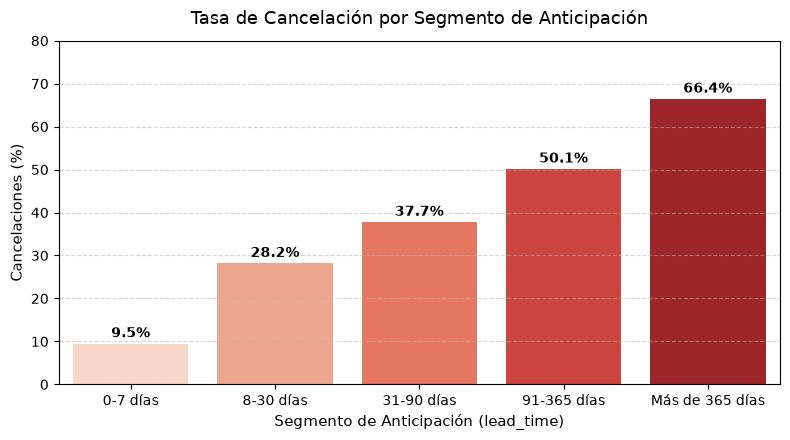

In [313]:
# Cálculo de la tasa de cancelación porcentual por cada segmento
datos_resumen = df.groupby('lead_time_segment', observed=False).agg(
    tasa_cancelacion=('is_canceled', lambda x: x.mean() * 100)
).reset_index()

# Creación y parametrización del gráfico
plt.figure(figsize=(8, 4.5))

ax = sns.barplot(
    data=datos_resumen,
    x='lead_time_segment', 
    y='tasa_cancelacion', 
    palette='Reds'
)

plt.title('Tasa de Cancelación por Segmento de Anticipación', fontsize=13, pad=12)
plt.xlabel('Segmento de Anticipación (lead_time)', fontsize=11)
plt.ylabel('Cancelaciones (%)', fontsize=11)
plt.ylim(0, 80)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Inclusión de las etiquetas con el porcentaje exacto sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    if np.isnan(altura):
        altura = 0
    ax.annotate(
        f"{altura:.1f}%", 
        (p.get_x() + p.get_width() / 2., altura + 1.5), 
        ha='center', 
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Se agrega a la bitacora

In [314]:
registrar(
    problema="Lead_time tiene muchos valores posibles y distribución sesgada",
    variable="lead_time_segment",
    decision="Se crea lead_time_segment mediante intervalos interpretables",
    justificacion="La discretización facilita comparar reservas inmediatas, de mediano plazo y anticipadas sin eliminar el valor original."
)

## Creacion de has_company y has_agent

Las columnas agent y company contienen los identificadores de la agencia de viajes o la empresa que gestionó la reserva. En ambas variables los valores nulos no son fallos de registro o datos perdidos al azar, sino ausencias que significan que no cuenta con aagente o empresa. Indica que la reserva fue hecha de manera particular y directa, sin intermediario ni convenio corporativo.

Crear las variables binarias has_agent y has_company permite simplificar esa información en un formato directo (1 si intervino un intermediario y 0 si fue directa), facilitando comparar si las reservas intermediadas cancelan más o menos que las particulares sin depender de cientos de identificadores numéricos dispersos.

In [315]:
# Creación de variables binarias indicadoras (1 = intervino / 0 = directo)
# Las ausencias ya se encuentra corregidas como ausente = 0 en las variables
df['has_agent'] = (df['agent'] != 0).astype('int8')
df['has_company'] = (df['company'] != 0).astype('int8')

# Verificación 
columnas_intermediarios = ['agent', 'has_agent', 'company', 'has_company']
print("Verificación de las primeras filas calculadas:")
display(df[columnas_intermediarios].head())

#Distribución de frecuencias y porcentajes
print("\nDistribución de frecuencias - has_agent:")
print(df['has_agent'].value_counts())
print("\nPorcentajes - has_agent:")
print(df['has_agent'].value_counts(normalize=True).round(4) * 100)

print("\nDistribución de frecuencias - has_company:")
print(df['has_company'].value_counts())
print("\nPorcentajes - has_company:")
print(df['has_company'].value_counts(normalize=True).round(4) * 100)

# Tasa de cancelación (%) según presencia de agente y empresa
print("\nCancelación por Agente:\n", (df.groupby('has_agent')['is_canceled'].mean() * 100).round(2))
print("\nCancelación por Empresa:\n", (df.groupby('has_company')['is_canceled'].mean() * 100).round(2))

Verificación de las primeras filas calculadas:


,agent,has_agent,company,has_company
0,0,0,292,1
1,240,1,0,0
2,240,1,0,0
3,9,1,0,0
4,0,0,0,0



Distribución de frecuencias - has_agent:
has_agent
1    21358
0     3429
Name: count, dtype: int64

Porcentajes - has_agent:
has_agent
1    86.17
0    13.83
Name: proportion, dtype: float64

Distribución de frecuencias - has_company:
has_company
0    23383
1     1404
Name: count, dtype: int64

Porcentajes - has_company:
has_company
0    94.34
1     5.66
Name: proportion, dtype: float64

Cancelación por Agente:
 has_agent
0    25.43
1    39.18
Name: is_canceled, dtype: float64

Cancelación por Empresa:
 has_company
0    38.46
1    17.66
Name: is_canceled, dtype: float64


**Impacto de los intermediarios (`has_agent` y `has_company`)**

- **`has_agent`** Concentra el **86,17%** de las operaciones del hotel. Las reservas gestionadas mediante agentes presentan una tasa de cancelación considerablemente mayor (**39,18%**) frente a las reservas directas (**25,43%**), lo que refleja el efecto de las facilidades de cancelación y la búsqueda de tarifas en plataformas externas.
- **Canal corporativo (`has_company`):** Representa un volumen minoritario (**5,66%** del total), mostrando que el perfil de huéspedes está dominado casi en su totalidad por viajeros particulares y turismo recreativo.

Estos contrastes confirman la utilidad de derivar ambas variables binarias para segmentar el riesgo de cancelación según el canal de origen.

### Market Segment y Distribution Channel

Ambas variables presentan categorías marginales con menos del 1% del total de registros (Aviation y Complementary en segmento. GDS en canal).  Agrupar estas clases poco frecuentes bajo la etiqueta 'Other' simplifica la estructura de los datos y previene la dispersión innecesaria al codificar, evitando crear columnas prácticamente vacías que no aportan valor predictivo 

In [316]:

# Agrupar categorías < 1% en market_segment ('Complementary' y 'Aviation')
df['market_segment'] = df['market_segment'].replace(['Complementary', 'Aviation'], 'Other')

# Agrupar categorías < 1% en distribution_channel ('GDS')
df['distribution_channel'] = df['distribution_channel'].replace('GDS', 'Other')

# Verificación de frecuencias
print("Frecuencias consolidadas - market_segment:")
print(df['market_segment'].value_counts())

print("\nFrecuencias consolidadas - distribution_channel:")
print(df['distribution_channel'].value_counts())



Frecuencias consolidadas - market_segment:
market_segment
Online TA        11764
Offline TA/TO     4975
Groups            4152
Direct            2611
Corporate         1100
Other              185
Name: count, dtype: int64

Frecuencias consolidadas - distribution_channel:
distribution_channel
TA/TO        20348
Direct        3009
Corporate     1391
Other           39
Name: count, dtype: int64


Se carga en la bitacora:

In [317]:
# 4. Asiento en la bitácora de transformación
registrar_transformacion(
    problema="Presencia de categorías con representación menor al 1% en market_segment (Aviation, Complementary) y distribution_channel (GDS)",
    variable="market_segment, distribution_channel",
    decision="Agrupación de categorías poco frecuentes bajo la etiqueta 'Other'",
    justificacion="Reduce la dispersión de categorías testimoniales y evita la creación de columnas dispersas o casi vacías."
)

### Has booking changes

Transformar los booking changes en la variable binaria has_booking_changes (1 si hubo al menos un cambio, 0 si no hubo) permite evaluar el compromiso del cliente y la probabilidad de no realizar una cancelacion

In [318]:


# Creación de la variable binaria (1 = con cambios, 0 = sin cambios)
df['has_booking_changes'] = (df['booking_changes'] > 0).astype('int8')

# Distribución y porcentaje
print("Frecuencias de has_booking_changes:")
print(df['has_booking_changes'].value_counts())
print("\nPorcentajes (%):")
print((df['has_booking_changes'].value_counts(normalize=True) * 100).round(2))

# Tasa de cancelación comparativa (%)
print("\nCancelación por has_booking_changes (%):")
print((df.groupby('has_booking_changes')['is_canceled'].mean() * 100).round(2))



Frecuencias de has_booking_changes:
has_booking_changes
0    21043
1     3744
Name: count, dtype: int64

Porcentajes (%):
has_booking_changes
0    84.9
1    15.1
Name: proportion, dtype: float64

Cancelación por has_booking_changes (%):
has_booking_changes
0    41.16
1    15.46
Name: is_canceled, dtype: float64


Es posible ver como si tiene cambios en la reserva, es menos probable que se realice una cancelacion.

Se guarda en la bitacora

In [319]:
# Registro en bitácora
registrar_transformacion(
    problema="booking_changes tiene más del 84% de valores en 0 y mucha cantidad de valores distintos positivos (mas de un cambio)",
    variable="has_booking_changes",
    decision="Creación de la variable binaria: 1 si booking_changes > 0, 0 en caso contrario",
    justificacion="Aísla el comportamiento de reservas, reduciendolas a si tiene o no."
)

## Bitacora de transformacion final:

In [320]:
print("Bitacora de transformacion:\n")
pd.DataFrame(transformacion_bitacora)


Bitacora de transformacion:



,problema_detectado,variable_afectada,decision_tomada,justificacion
0,Conocer el total de ocupación de la reserva en...,total_gests,"Suma de adults, children y babies","Se crea total_guests, muestra tamaño total del..."
1,Diferenciar reservas de adultos y de grupos fa...,is_family,Creación de variable binaria: 1 si (children >...,Simplifica la lectura del perfil del cliente y...
2,La duración completa de la estadía se encuentr...,total_stay_nights,Derivación por suma: stays_in_weekend_nights m...,Permite mostrar en una sola métrica la duració...
3,Necesidad de estimar el importe total de cada ...,estimated_stay_amount,Crear estimated_stay_amount como producto de a...,El importe estimado resume el valor de la rese...
4,Presencia de categorías con representación men...,"market_segment, distribution_channel",Agrupación de categorías poco frecuentes bajo ...,Reduce la dispersión de categorías testimonial...
5,booking_changes tiene más del 84% de valores e...,has_booking_changes,Creación de la variable binaria: 1 si booking_...,"Aísla el comportamiento de reservas, reduciend..."


## Resumen de los cambios realizados 

Verificacion de los datos:

In [321]:
columnas_nuevas = [
    'has_agent', 'has_company', 'total_stay_nights', 'total_guests',
    'estimated_stay_amount', 'is_family', 'has_booking_changes', 'lead_time_segment'
]

# VALIDACIONES DE INTEGRIDAD GENERAL Y TAMAÑO
registros_eliminados = len(df_original) - len(df)
assert registros_eliminados >= 0, "Error: Las filas finales no pueden superar a las originales"
assert len(df) == len(df_original) - registros_eliminados, "Error: Discrepancia en el conteo de registros eliminados"
assert df[columnas_nuevas].notna().all().all(), "Error: Existen valores nulos en las columnas nuevas"

# VALIDACIONES DE LIMPIEZA (REGLAS DE NEGOCIO Y CONSISTENCIA)

# Validar eliminación de inconsistencias operativas (noches, huéspedes y adultos)
assert (df['total_stay_nights'] > 0).all(), "Error: Quedaron reservas con 0 noches de estadía"
assert (df['total_guests'] > 0).all(), "Error: Quedaron reservas con 0 huéspedes totales"
assert (df['adults'] > 0).all(), "Error: Quedaron reservas sin adultos responsables"

# Validar depuración de outliers imposibles y errores contables
assert (df['adr'] >= 0).all(), "Error: Se detectaron tarifas diarias (ADR) negativas"

# Validar unificación de categorías y tratamiento de nulos
assert 'Undefined' not in df['meal'].values, "Error: La categoría Undefined en meal no fue reemplazada"
assert df['agent'].isnull().sum() == 0 and df['company'].isnull().sum() == 0, "Error: Quedan valores nulos en agent o company"


#VALIDACIONES DE TRANSFORMACIÓN (INDICADORES BINARIOS Y AGRUPACIONES)

# Validar que las variables binarias solo contengan valores {0, 1}
columnas_binarias = ['has_agent', 'has_company', 'is_family', 'has_booking_changes']
for col in columnas_binarias:
    assert set(df[col].unique()).issubset({0, 1}), f"Error: {col} contiene valores distintos de 0 y 1"

# Validar que las categorías minoritarias fueron agrupadas en 'Other'
assert not set(['Aviation', 'Complementary']).intersection(set(df['market_segment'].unique())), "Error: Categorías minoritarias en market_segment no agrupadas"
assert 'GDS' not in df['distribution_channel'].values, "Error: La categoría GDS no fue agrupada en distribution_channel"

# Validar que el importe estimado no sea negativo
assert (df['estimated_stay_amount'] >= 0).all(), "Error: estimated_stay_amount contiene valores negativos"

print("Todas las validaciones pasaron correctamente.")


# 4. SALIDA INFORMATIVA DEL ESTADO FINAL

print('Filas originales:', len(df_original))
print('Registros eliminados durante la limpieza:', registros_eliminados)
print('Filas del dataset preparado:', len(df))
print('Columnas:', len(df.columns))
print('\nColumnas Nuevas (Nuevas variables):')
print(columnas_nuevas)
print('\nVista del dataset preparado:')
display(df.head())

Todas las validaciones pasaron correctamente.
Filas originales: 25000
Registros eliminados durante la limpieza: 213
Filas del dataset preparado: 24787
Columnas: 39

Columnas Nuevas (Nuevas variables):
['has_agent', 'has_company', 'total_stay_nights', 'total_guests', 'estimated_stay_amount', 'is_family', 'has_booking_changes', 'lead_time_segment']

Vista del dataset preparado:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,stays_in_week_nights,...,required_car_parking_spaces,total_of_special_requests,total_guests,is_family,total_stay_nights,estimated_stay_amount,lead_time_segment,has_agent,has_company,has_booking_changes
0,Resort Hotel,0,17,2025,February,8,21,2025-02-21,0,1,...,1,1,1,0,1,58.00,8-30 días,0,1,0
1,Resort Hotel,0,6,2023,November,44,1,2023-11-01,2,1,...,0,2,1,0,3,174.00,0-7 días,1,0,1
2,Resort Hotel,0,45,2024,April,15,8,2024-04-08,0,1,...,0,2,2,0,1,65.00,31-90 días,1,0,1
3,City Hotel,0,95,2024,March,11,17,2024-03-17,2,3,...,0,1,2,0,5,369.75,91-365 días,1,0,0
4,City Hotel,1,277,2024,November,45,7,2024-11-07,1,2,...,0,0,2,0,3,300.00,91-365 días,0,0,0


## Resumen metodológico: Limpieza vs. Transformación

### 1. Fase de Limpieza (Curación de datos)
* **Eliminación de atributos sin valor analítico:** Se descartaron `booking_id` (identificador único sin capacidad predictiva) y `arrival_date_week_number` (redundancia temporal frente al año, mes y día de llegada).
* **Tratamiento de inconsistencias lógicas (filtrado de registros):** Se solucionaron anomalías operativas eliminando reservas sin pernocte (estadía de 0 noches), reservas sin ocupantes o con menores de edad sin adultos a cargo, errores tipográficos imposibles (`babies >= 9`) y un registro erróneo de tarifa negativa (`adr < 0`).
* **Corrección de tipos y unificación de categorías:** Se reclasificó `'Undefined'` como `'SC'` (*Self Catering*) en la variable `meal`, se transformó `children` al tipo discreto entero (`int64`) y se imputaron con `0` las ausencias estructurales en `agent` y `company` (indicando reservas directas y particulares).

### 2. Fase de Transformación
* **Derivación de totales e importes agregados:** Mediante operaciones aritméticas, se sintetizaron métricas globales como `total_guests` (suma total de personas), `total_stay_nights` (duración total del alojamiento uniendo días hábiles y fines de semana) y `estimated_stay_amount` (producto entre la tarifa diaria `adr` y las noches totales)
* **Creación de variables binarias indicadoras:** Se generaron banderas codificadas en `{0, 1}` para aislar comportamientos predictivos clave: `is_family` (presencia de menores), `has_agent` (intermediación comercial), `has_company` (origen corporativo) y `has_booking_changes` (gestión activa de la reserva
* **Consolidación de categorías marginales:** Se agruparon aquellas clases con frecuencias inferiores al 1% bajo la etiqueta `'Other'` (`Aviation` y `Complementary` en `market_segment`; `GDS` en `distribution_channel`), previniendo la dispersión de columnas en futuras codificaciones
* **Discretización:** Se segmentó `lead_time` en rangos temporales homogéneos para facilitar el análisis por ventanas de anticipación sin verse distorsionado por la asimetría de valores atípicos.

---

## ¿Cómo quedó preparado el dataset?

El conjunto de datos quedó consolidado como una **matriz depurada, consistente y enriquecida para el análisis del negocio**:

1. **Integridad operacional asegurada:** No contiene registros incompletos, reservas ficticias sin ocupantes ni distorsiones de facturación, asegurando que cada fila represente un suceso realista del dataset.
2. **Estructura dimensional controlada:** Se eliminó el ruido provocado por identificadores internos y redundancias de calendario, controlando además la dispersión de categorías testimoniales al unificarlas en `'Other'`.
3. **Ausencias contextualizadas numéricamente:** Los identificadores de intermediación (`agent` y `company`) fueron binarizados, evitando la presencia de nulos que distorsionen los cálculos algorítmicos.
4. **Mayor potencia predictiva sobre la cancelación:** Se generaron atributos de volumen, compromiso del cliente (modificaciones) y tipo de canal, aislando los segmentos de mayor y menor riesgo respecto a la variable objetivo `is_canceled`.
5. **Aptitud para modelado y exploración:** Los datos se encuentran en un estado óptimo para continuar con el trabajo